In [1]:
import pandas as pd
df=pd.read_csv('googleplaystore.csv')
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [2]:
df.shape

(10841, 13)

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [4]:
df.dtypes

App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

In [5]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [6]:
print("Play store dataset columns",df.columns)

Play store dataset columns Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')


CHECKING NULL VALUES


In [7]:
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

PLOTTING NULL VALUES

<Axes: >

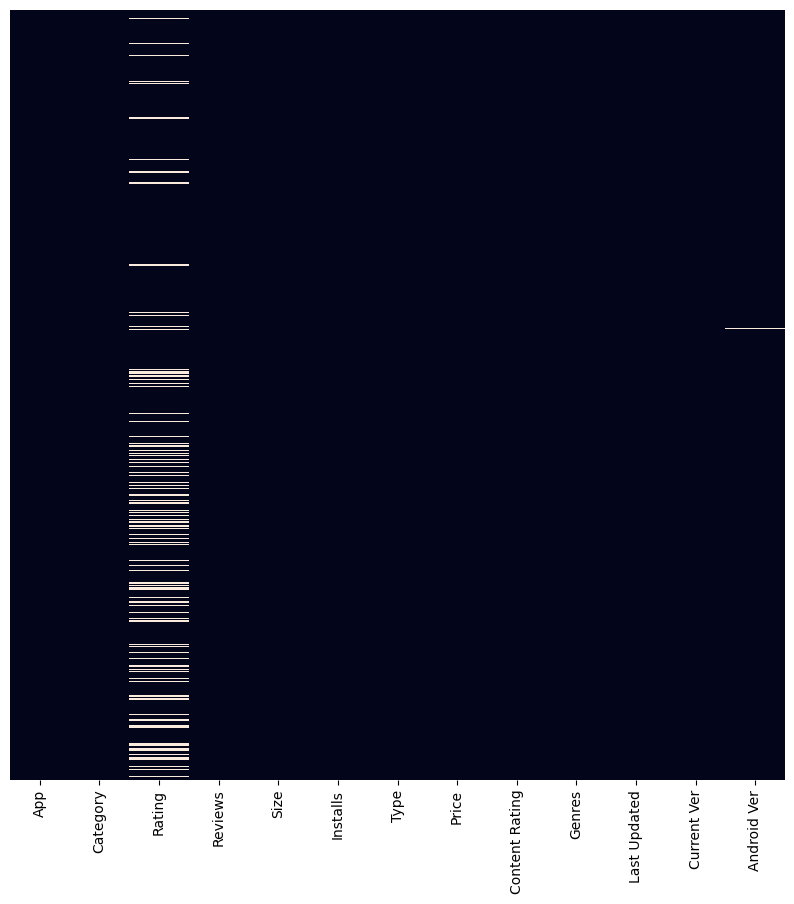

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,10))
sns.heatmap(df.isnull(),yticklabels=False,cbar=False)

we have to clean following columns:
Reviews : It has to be a numerical column and datatype into int/float
Size : Every Entry has "M" and "K" which needs to be removed and datatype into int/float
Installs: Every entry has "+" at the end which needs to be removed and datatype into int/float also it has entries like "Free"
Price : It has "$" at the begining it needs to be cleaned and datatype into int/float
LastUpdtaed : it is date time column ,datatype shouldbe changed accordingly and in feature engineering we will splitt the column into year and month
Current Ver : The entries are 1.0.1,1.2.1,1.2 so we will make it 101,121,120 , correct upto 3 places
Android Ver : we will remove "And up" from the end and making 4.0.3 as 403


Also Rating can be treated as the target column and the rest features can be treated as independent i.e what makes an app better in rating

DATASET ROWS AND COLUMNS

In [9]:
print("play store data rows count:",df.shape[0])
print("play store Data columns count:",df.shape[1])


play store data rows count: 10841
play store Data columns count: 13


DUPLICATE VALUES

In [10]:
df[df.duplicated()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
229,Quick PDF Scanner + OCR FREE,BUSINESS,4.2,80805,Varies with device,"5,000,000+",Free,0,Everyone,Business,"February 26, 2018",Varies with device,4.0.3 and up
236,Box,BUSINESS,4.2,159872,Varies with device,"10,000,000+",Free,0,Everyone,Business,"July 31, 2018",Varies with device,Varies with device
239,Google My Business,BUSINESS,4.4,70991,Varies with device,"5,000,000+",Free,0,Everyone,Business,"July 24, 2018",2.19.0.204537701,4.4 and up
256,ZOOM Cloud Meetings,BUSINESS,4.4,31614,37M,"10,000,000+",Free,0,Everyone,Business,"July 20, 2018",4.1.28165.0716,4.0 and up
261,join.me - Simple Meetings,BUSINESS,4.0,6989,Varies with device,"1,000,000+",Free,0,Everyone,Business,"July 16, 2018",4.3.0.508,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8643,Wunderlist: To-Do List & Tasks,PRODUCTIVITY,4.6,404610,Varies with device,"10,000,000+",Free,0,Everyone,Productivity,"April 6, 2018",Varies with device,Varies with device
8654,"TickTick: To Do List with Reminder, Day Planner",PRODUCTIVITY,4.6,25370,Varies with device,"1,000,000+",Free,0,Everyone,Productivity,"August 6, 2018",Varies with device,Varies with device
8658,ColorNote Notepad Notes,PRODUCTIVITY,4.6,2401017,Varies with device,"100,000,000+",Free,0,Everyone,Productivity,"June 27, 2018",Varies with device,Varies with device
10049,Airway Ex - Intubate. Anesthetize. Train.,MEDICAL,4.3,123,86M,"10,000+",Free,0,Everyone,Medical,"June 1, 2018",0.6.88,5.0 and up


UNDERSTANDING OUR  VARIABLES

REVIEWS

In [11]:
df.Reviews.head()

0       159
1       967
2     87510
3    215644
4       967
Name: Reviews, dtype: object

In [12]:
df.Reviews

0           159
1           967
2         87510
3        215644
4           967
          ...  
10836        38
10837         4
10838         3
10839       114
10840    398307
Name: Reviews, Length: 10841, dtype: object

In [13]:
# df.Reviews=df.Reviews.astype(int)

from the above operation i get to know that there is 3.0m to convertedd in numeric

In [14]:
df[df.Reviews=='3.0M']

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [15]:
df.loc[10472,'Reviews']=3000000


In [16]:
df.Reviews=df.Reviews.astype(int)

ONLY RATING IS A NUMBER COLUMN

In [17]:
df.describe()

,Rating,Reviews
count,9367.000000,1.084100e+04
mean,4.193338,4.443887e+05
std,0.537431,2.927728e+06
min,1.000000,0.000000e+00
25%,4.000000,3.800000e+01
50%,4.300000,2.094000e+03
75%,4.500000,5.479800e+04
max,19.000000,7.815831e+07


In [18]:
df.describe(include="all")

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
count,10841,10841,9367.000000,1.084100e+04,10841,10841,10840,10841,10840,10841,10841,10833,10838
unique,9660,34,NaN,NaN,462,22,3,93,6,120,1378,2832,33
top,ROBLOX,FAMILY,NaN,NaN,Varies with device,"1,000,000+",Free,0,Everyone,Tools,"August 3, 2018",Varies with device,4.1 and up
freq,9,1972,NaN,NaN,1695,1579,10039,10040,8714,842,326,1459,2451
mean,NaN,NaN,4.193338,4.443887e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,0.537431,2.927728e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,3.800000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,4.300000,2.094000e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,4.500000,5.479800e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


WORKING ON SIZE COLUMN

In [19]:
df['Size']

0                       19M
1                       14M
2                      8.7M
3                       25M
4                      2.8M
                ...        
10836                   53M
10837                  3.6M
10838                  9.5M
10839    Varies with device
10840                   19M
Name: Size, Length: 10841, dtype: object

In [20]:
df['Size'].hasnans

False

In [21]:
df[df['Size'].apply(lambda x: 'm' in x.lower())]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10835,FR Forms,BUSINESS,NaN,0,9.6M,10+,Free,0,Everyone,Business,"September 29, 2016",1.1.5,4.0 and up
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up


In [22]:
len(df[df['Size'].apply(lambda x: 'm' in x.lower())])

8829

In [23]:
df[df['Size'].apply(lambda x: 'k' in x.lower())]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
58,Restart Navigator,AUTO_AND_VEHICLES,4.0,1403,201k,"100,000+",Free,0,Everyone,Auto & Vehicles,"August 26, 2014",1.0.1,2.2 and up
209,Plugin:AOT v5.0,BUSINESS,3.1,4034,23k,"100,000+",Free,0,Everyone,Business,"September 11, 2015",3.0.1.11 (Build 311),2.2 and up
384,Hangouts Dialer - Call Phones,COMMUNICATION,4.0,122498,79k,"10,000,000+",Free,0,Everyone,Communication,"September 2, 2015",0.1.100944346,4.0.3 and up
450,Caller ID +,COMMUNICATION,4.0,9498,118k,"1,000,000+",Free,0,Everyone,Communication,"June 7, 2016",5.28.0,2.3 and up
458,GO Notifier,COMMUNICATION,4.2,124346,695k,"10,000,000+",Free,0,Everyone,Communication,"July 6, 2014",2.8,2.0 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10763,FP Разбитый дисплей,FAMILY,4.5,922,552k,"50,000+",Free,0,Everyone,Entertainment,"September 20, 2014",1.1,1.6 and up
10764,FP Transportation,AUTO_AND_VEHICLES,NaN,1,885k,1+,Free,0,Everyone,Auto & Vehicles,"March 9, 2018",10.0.0,4.0 and up
10798,Word Search Tab 1 FR,FAMILY,NaN,0,1020k,50+,Paid,$1.04,Everyone,Puzzle,"February 6, 2012",1.1,3.0 and up
10832,FR Tides,WEATHER,3.8,1195,582k,"100,000+",Free,0,Everyone,Weather,"February 16, 2014",6.0,2.1 and up


In [24]:
df[df['Size'].apply(lambda x: 'varies with device' in x.lower())]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
37,Floor Plan Creator,ART_AND_DESIGN,4.1,36639,Varies with device,"5,000,000+",Free,0,Everyone,Art & Design,"July 14, 2018",Varies with device,2.3.3 and up
42,Textgram - write on photos,ART_AND_DESIGN,4.4,295221,Varies with device,"10,000,000+",Free,0,Everyone,Art & Design,"July 30, 2018",Varies with device,Varies with device
52,Used Cars and Trucks for Sale,AUTO_AND_VEHICLES,4.6,17057,Varies with device,"1,000,000+",Free,0,Everyone,Auto & Vehicles,"July 30, 2018",Varies with device,Varies with device
67,Ulysse Speedometer,AUTO_AND_VEHICLES,4.3,40211,Varies with device,"5,000,000+",Free,0,Everyone,Auto & Vehicles,"July 30, 2018",Varies with device,Varies with device
68,REPUVE,AUTO_AND_VEHICLES,3.9,356,Varies with device,"100,000+",Free,0,Everyone,Auto & Vehicles,"May 25, 2018",Varies with device,Varies with device
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10713,My Earthquake Alerts - US & Worldwide Earthquakes,WEATHER,4.4,3471,Varies with device,"100,000+",Free,0,Everyone,Weather,"July 24, 2018",Varies with device,Varies with device
10725,Posta App,MAPS_AND_NAVIGATION,3.6,8,Varies with device,"1,000+",Free,0,Everyone,Maps & Navigation,"September 27, 2017",Varies with device,4.4 and up
10765,Chat For Strangers - Video Chat,SOCIAL,3.4,622,Varies with device,"100,000+",Free,0,Mature 17+,Social,"May 23, 2018",Varies with device,Varies with device
10826,Frim: get new friends on local chat rooms,SOCIAL,4.0,88486,Varies with device,"5,000,000+",Free,0,Mature 17+,Social,"March 23, 2018",Varies with device,Varies with device


In [25]:
df["Size"]=df["Size"].str.replace("M","")
df["Size"]=df["Size"].str.replace("Varies with device","0")






HEMCE ALL THE SIZES ARE IN MEGABYTES

In [26]:

def kb_to_mb(size):
    return float(size.lower().replace('k', '')) / 1024

df['Size'] = df['Size'].astype(str).fillna('')
df.loc[df['Size'].apply(lambda x: 'k' in x.lower()), 'Size'] = df[df['Size'].apply(lambda x: 'k' in x.lower())]['Size'].apply(kb_to_mb)

df["Size"]#size in megabytes



0         19
1         14
2        8.7
3         25
4        2.8
        ... 
10836     53
10837    3.6
10838    9.5
10839      0
10840     19
Name: Size, Length: 10841, dtype: object

In [27]:
df["Size"]=df["Size"].str.replace("+","").str.replace(",","").astype(float)

In [28]:
df["Size"].hasnans

True

In [29]:
df[df["Size"].isna()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
58,Restart Navigator,AUTO_AND_VEHICLES,4.0,1403,NaN,"100,000+",Free,0,Everyone,Auto & Vehicles,"August 26, 2014",1.0.1,2.2 and up
209,Plugin:AOT v5.0,BUSINESS,3.1,4034,NaN,"100,000+",Free,0,Everyone,Business,"September 11, 2015",3.0.1.11 (Build 311),2.2 and up
384,Hangouts Dialer - Call Phones,COMMUNICATION,4.0,122498,NaN,"10,000,000+",Free,0,Everyone,Communication,"September 2, 2015",0.1.100944346,4.0.3 and up
450,Caller ID +,COMMUNICATION,4.0,9498,NaN,"1,000,000+",Free,0,Everyone,Communication,"June 7, 2016",5.28.0,2.3 and up
458,GO Notifier,COMMUNICATION,4.2,124346,NaN,"10,000,000+",Free,0,Everyone,Communication,"July 6, 2014",2.8,2.0 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10763,FP Разбитый дисплей,FAMILY,4.5,922,NaN,"50,000+",Free,0,Everyone,Entertainment,"September 20, 2014",1.1,1.6 and up
10764,FP Transportation,AUTO_AND_VEHICLES,NaN,1,NaN,1+,Free,0,Everyone,Auto & Vehicles,"March 9, 2018",10.0.0,4.0 and up
10798,Word Search Tab 1 FR,FAMILY,NaN,0,NaN,50+,Paid,$1.04,Everyone,Puzzle,"February 6, 2012",1.1,3.0 and up
10832,FR Tides,WEATHER,3.8,1195,NaN,"100,000+",Free,0,Everyone,Weather,"February 16, 2014",6.0,2.1 and up


In [30]:
df["Size"] = df["Size"].dropna().reset_index(drop=True)


In [31]:
import numpy as np
df["Size"].replace('', np.nan, inplace=True)
df["Size"].replace('NaN', np.nan, inplace=True)
df.dropna(subset=["Size"], inplace=True)


/tmp/ipykernel_8690/1346608304.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Size"].replace('', np.nan, inplace=True)
/tmp/ipykernel_8690/1346608304.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [32]:
df["Size"].hasnans

False

In [33]:
df=df.rename(columns={"Size":"Size in mb"})
df

,App,Category,Rating,Reviews,Size in mb,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10520,Driving Suv Toyota Car Simulator,FAMILY,3.7,187,53.0,"10,000+",Free,0,Everyone,Simulation,"November 12, 2017",1,4.0 and up
10521,Navy Gunner Shoot War 3D,GAME,4.0,103199,3.6,"10,000,000+",Free,0,Teen,Action,"August 2, 2018",1.0.7.8,4.2 and up
10522,Drift Legends,GAME,4.2,33788,9.5,"1,000,000+",Free,0,Everyone,Racing,"March 29, 2018",1.8.5,4.1 and up
10523,FK,MEDICAL,4.4,1517,0.0,"100,000+",Free,0,Everyone,Medical,"July 13, 2018",2.5.9,2.3 and up


In [34]:
df.tail()

,App,Category,Rating,Reviews,Size in mb,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10520,Driving Suv Toyota Car Simulator,FAMILY,3.7,187,53.0,"10,000+",Free,0,Everyone,Simulation,"November 12, 2017",1,4.0 and up
10521,Navy Gunner Shoot War 3D,GAME,4.0,103199,3.6,"10,000,000+",Free,0,Teen,Action,"August 2, 2018",1.0.7.8,4.2 and up
10522,Drift Legends,GAME,4.2,33788,9.5,"1,000,000+",Free,0,Everyone,Racing,"March 29, 2018",1.8.5,4.1 and up
10523,FK,MEDICAL,4.4,1517,0.0,"100,000+",Free,0,Everyone,Medical,"July 13, 2018",2.5.9,2.3 and up
10524,FK (FlightKid),GAME,NaN,2,19.0,10+,Free,0,Everyone,Action,"March 3, 2016",1.0,4.0 and up


INSTALLS

In [35]:

df["Installs"]=df["Installs"].str.replace('+',"")
df["Installs"].to_frame()

,Installs
0,"10,000"
1,"500,000"
2,"5,000,000"
3,"50,000,000"
4,"100,000"
...,...
10520,"10,000"
10521,"10,000,000"
10522,"1,000,000"
10523,"100,000"


In [36]:
df["Installs"]=df["Installs"].str.replace(",","")
df["Installs"]

0           10000
1          500000
2         5000000
3        50000000
4          100000
           ...   
10520       10000
10521    10000000
10522     1000000
10523      100000
10524          10
Name: Installs, Length: 10525, dtype: object

In [37]:
df["Installs"].unique()

array(['10000', '500000', '5000000', '50000000', '100000', '50000',
       '1000000', '10000000', '5000', '100000000', '1000000000', '1000',
       '500000000', '50', '100', '500', '10', '1', '5', '0', 'Free'],
      dtype=object)

In [38]:
df[df.loc[:,"Installs"]=="Free"].index

Index([10472], dtype='int64')

In [39]:
#droping the row having free and resetingg the index
df.loc[10472]


App               Life Made WI-Fi Touchscreen Photo Frame
Category                                              1.9
Rating                                               19.0
Reviews                                           3000000
Size in mb                                            9.5
Installs                                             Free
Type                                                    0
Price                                            Everyone
Content Rating                                        NaN
Genres                                  February 11, 2018
Last Updated                                       1.0.19
Current Ver                                    4.0 and up
Android Ver                                           NaN
Name: 10472, dtype: object

In [40]:
df.drop(10472, inplace=True)
df.reset_index(drop=True, inplace=True)


ALSO DATATYPE HAS TO BE CHANGED

In [41]:
df["Installs"] = df["Installs"].astype(int)# as there are commmas and free before i was doing it was not hoying


In [42]:
bins = [-1, 0, 10, 1000, 10000, 100000, 1000000, 10000000, 10000000000]
labels=['no', 'Very low', 'Low', 'Moderate', 'More than moderate', 'High', 'Very High', 'Top Notch']
df['Installs_category'] = pd.cut(df['Installs'], bins=bins, labels=labels)


In [43]:

df['Installs_category'].value_counts() # check the value counts of the new column

Installs_category
High                  2094
Low                   2057
Very High             1987
More than moderate    1601
Moderate              1465
Top Notch              825
Very low               480
no                      15
Name: count, dtype: int64

In [44]:
df.head()

,App,Category,Rating,Reviews,Size in mb,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_category
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,Moderate
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,High
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,Very High
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,Top Notch
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,More than moderate


In [45]:
df.isnull().sum()

App                     0
Category                0
Rating               1368
Reviews                 0
Size in mb              0
Installs                0
Type                    1
Price                   0
Content Rating          0
Genres                  0
Last Updated            0
Current Ver             8
Android Ver             2
Installs_category       0
dtype: int64

In [46]:

# length before removing null values
print(f"Length of the dataframe before removing null values: {len(df)}")

Length of the dataframe before removing null values: 10524


In [47]:

df.dropna(subset=['Current Ver', 'Android Ver',  'Type'], inplace=True)

In [48]:
print(f"Length of the dataframe after removing null values: {len(df)}")

Length of the dataframe after removing null values: 10513


TREND OF RATING IN EACH INSTALL CATEGORY

In [49]:
df.groupby('Installs_category')['Rating'].describe()

/tmp/ipykernel_8690/520456251.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Installs_category')['Rating'].describe()


,count,mean,std,min,25%,50%,75%,max
Installs_category,,,,,,,,
no,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Very low,77.0,4.663636,0.785210,1.0,4.8,5.0,5.0,5.0
Low,1223.0,4.162796,0.828362,1.0,3.8,4.4,4.8,5.0
Moderate,1379.0,4.036911,0.607495,1.4,3.8,4.2,4.5,5.0
More than moderate,1570.0,4.094076,0.506211,1.6,3.9,4.2,4.5,4.9
High,2089.0,4.206319,0.377642,1.8,4.0,4.3,4.5,4.9
Very High,1987.0,4.287972,0.295350,2.0,4.1,4.3,4.5,4.9
Top Notch,825.0,4.375273,0.192882,3.1,4.3,4.4,4.5,4.8


WORKING ON RATING 

In [50]:
df["Rating"].to_frame()


,Rating
0,4.1
1,3.9
2,4.7
3,4.5
4,4.3
...,...
10519,3.7
10520,4.0
10521,4.2
10522,4.4


In [51]:
df["Rating"].isnull().sum()

np.int64(1363)

In [52]:
df["Rating"]=df["Rating"].dropna()

In [53]:
df["Rating"].fillna(df["Rating"].median(),inplace=True)

/tmp/ipykernel_8690/723172565.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Rating"].fillna(df["Rating"].median(),inplace=True)


In [54]:
df["Rating"].to_frame()

,Rating
0,4.1
1,3.9
2,4.7
3,4.5
4,4.3
...,...
10519,3.7
10520,4.0
10521,4.2
10522,4.4


In [55]:
df["Rating"].dtype

dtype('float64')

In [56]:
# in which Install_category the Rating has NaN values
df['Installs_category'].loc[df['Rating'].isnull()].value_counts()


Installs_category
no                    0
Very low              0
Low                   0
Moderate              0
More than moderate    0
High                  0
Very High             0
Top Notch             0
Name: count, dtype: int64

Text(7, 3.5, 'Null values: 0')

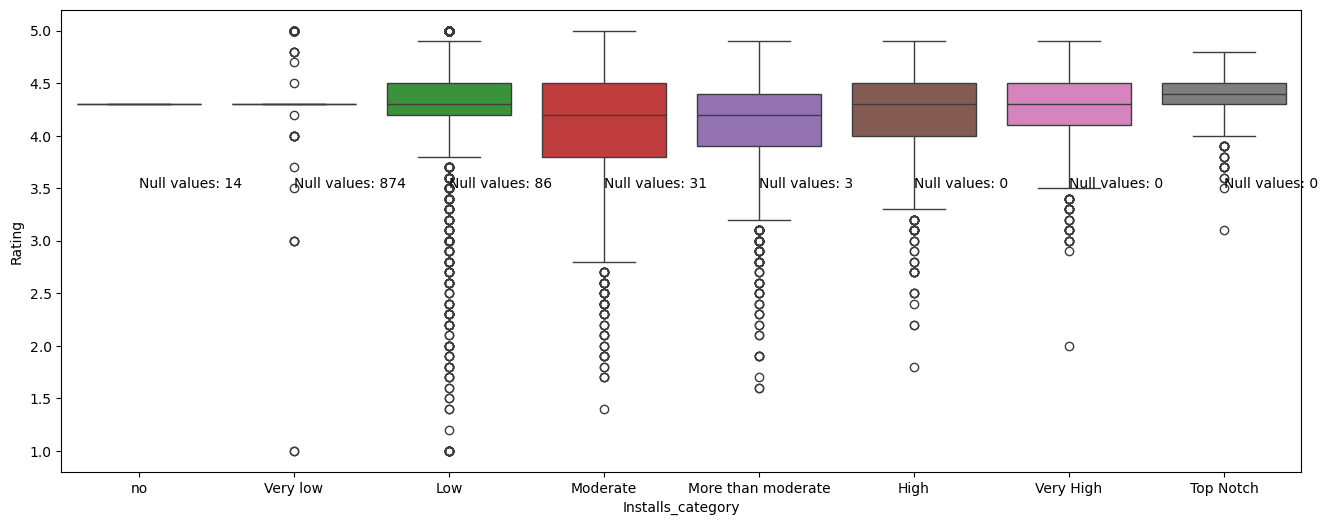

In [57]:
# plot the boxplot of Rating in each Installs_category
plt.figure(figsize=(16, 6)) # make figure size
sns.boxplot(x='Installs_category', y='Rating', hue='Installs_category', data=df) # plot the boxplot
# add the text of number of null values in each category
plt.text(0, 3.5, 'Null values: 14')
plt.text(1, 3.5, 'Null values: 874')
plt.text(2, 3.5, 'Null values: 86')
plt.text(3, 3.5, 'Null values: 31')
plt.text(4, 3.5, 'Null values: 3')
plt.text(5, 3.5, 'Null values: 0')
plt.text(6, 3.5, 'Null values: 0')
plt.text(7, 3.5, 'Null values: 0')

Let's check if there is any similar link with Reviews as well

In [58]:
# in which Install_category the Rating has NaN values
df['Installs_category'].loc[df['Reviews'].isnull()].value_counts()

Installs_category
no                    0
Very low              0
Low                   0
Moderate              0
More than moderate    0
High                  0
Very High             0
Top Notch             0
Name: count, dtype: int64

<Axes: xlabel='Installs_category', ylabel='Reviews'>

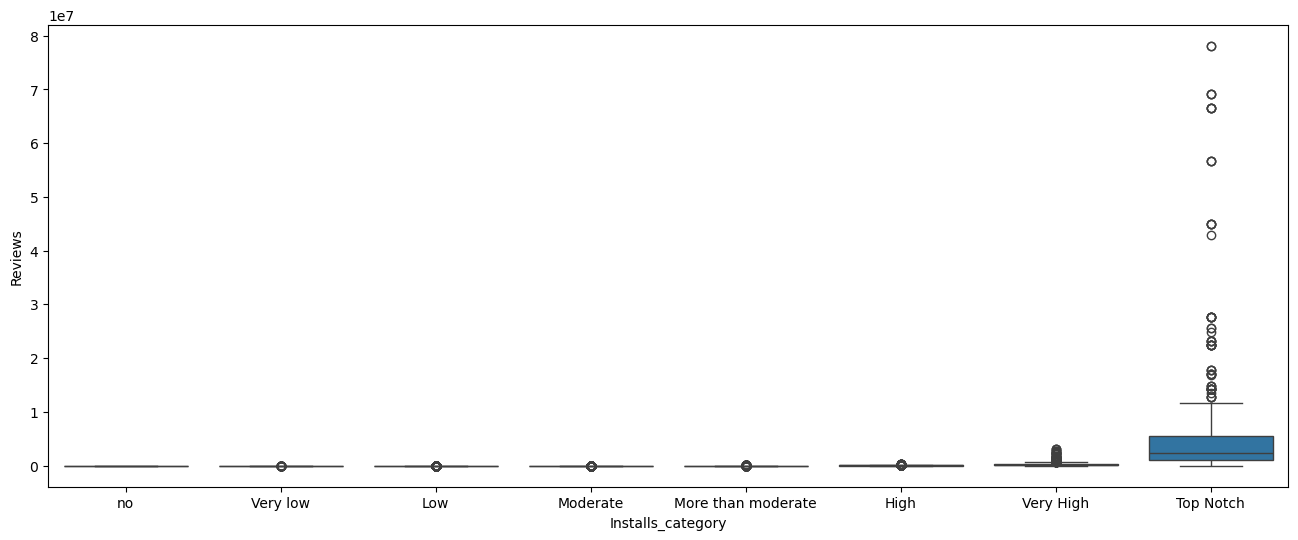

In [59]:

# let's plot the same plots for Reviews column as well
plt.figure(figsize=(16, 6)) # make figure size
sns.boxplot(x='Installs_category', y= 'Reviews', data=df) # plot the boxplot

/home/sai-satyam/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='Installs_category', ylabel='Reviews'>

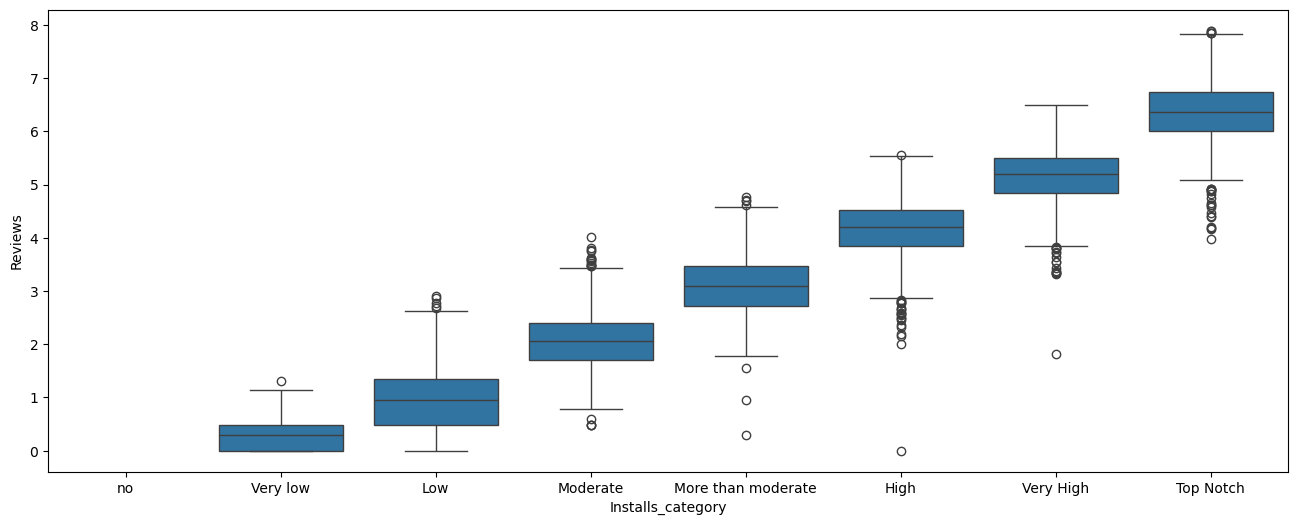

In [60]:
#  let's plot the same plots for Reviews column as well
plt.figure(figsize=(16, 6)) # make figure size
sns.boxplot(x='Installs_category', y= np.log10(df['Reviews']), data=df) # plot the boxplot

We also draw the scatter plot of the Rating and Review columns with the Installs column

<Axes: xlabel='Rating', ylabel='Reviews'>

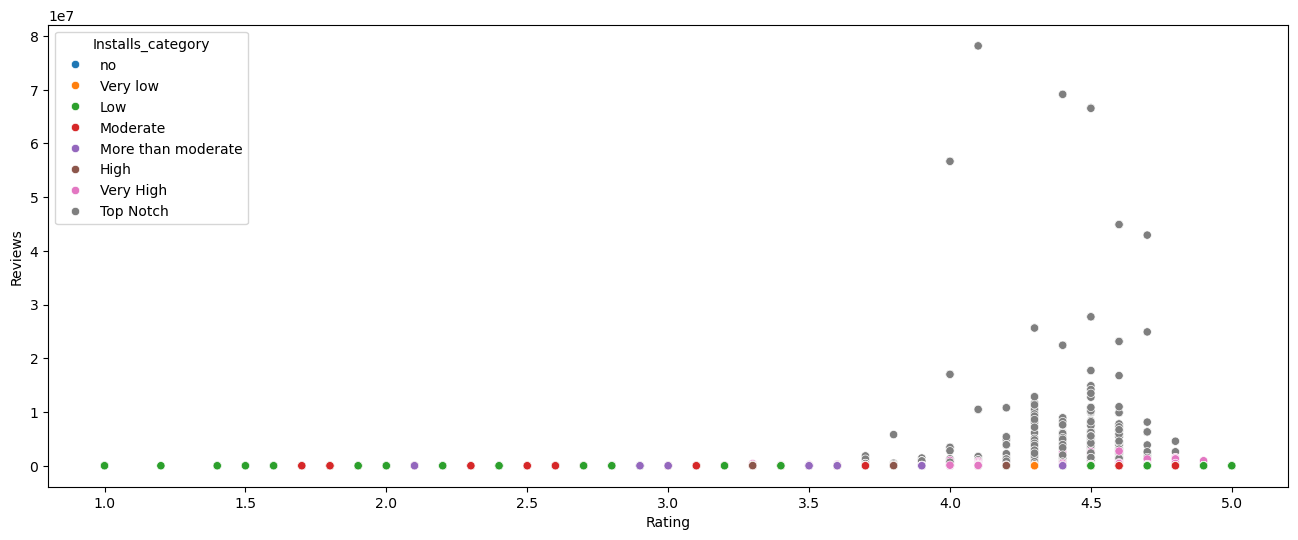

In [61]:
plt.figure(figsize=(16, 6)) # make figure size
sns.scatterplot(x='Rating', y='Reviews', hue='Installs_category', data=df) # plot the scatter plot

It doesn't show any trend, because, you should know that Rating is a categorical variable (Ordinal) and Reviews is a continuous variable, therefore, we can not plot them together.
Let's try with Reviews and Installs

<Axes: xlabel='Reviews', ylabel='Installs'>

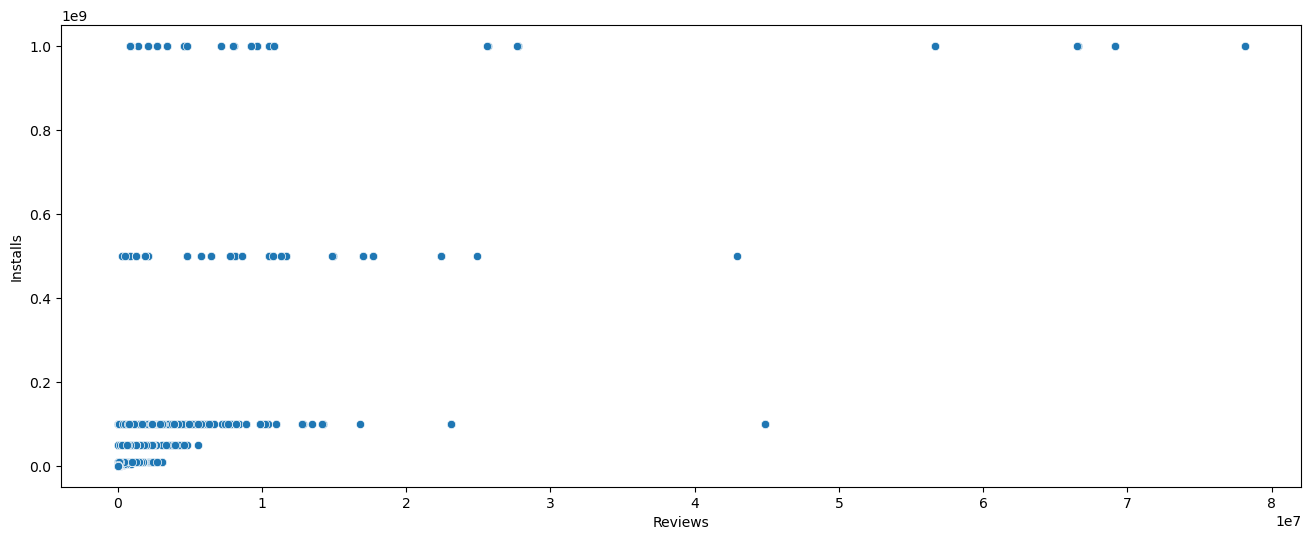

In [62]:

# plot reviews and installs in a scatter plot
plt.figure(figsize=(16, 6)) # make figure size
sns.scatterplot(x='Reviews', y='Installs', data=df) # plot the scatter plot


We did not see any trend and the issue is we need to normalize the data before plotting it, let's try with log transformation

/home/sai-satyam/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='Reviews', ylabel='Installs'>

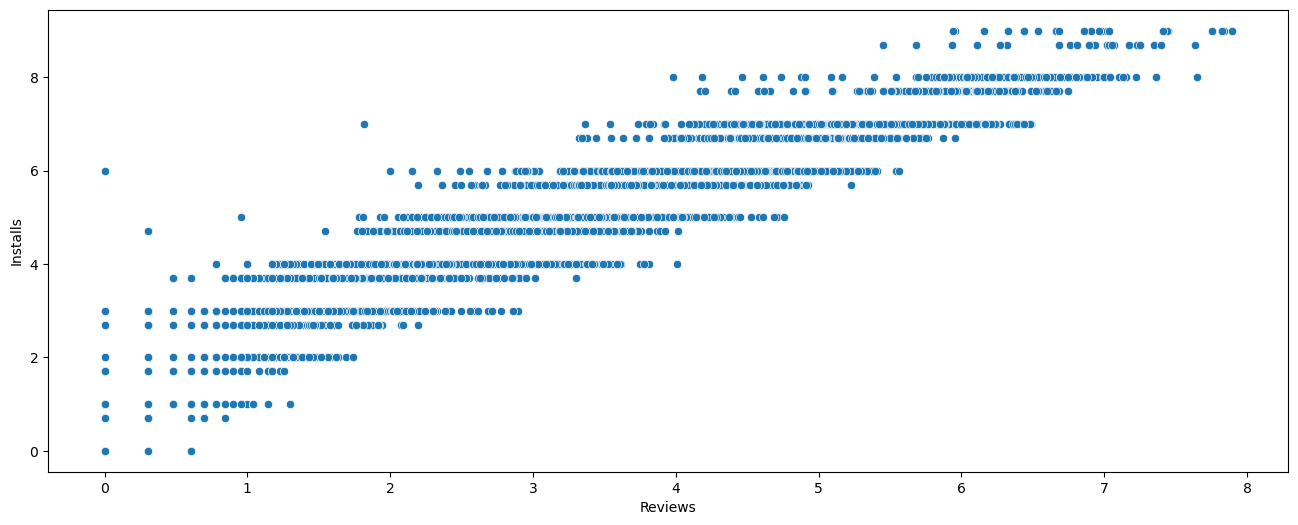

In [63]:
plt.figure(figsize=(16, 6)) # make figure size
sns.scatterplot(x=np.log10(df['Reviews']), y=np.log10(df['Installs']), data=df) # plot the scatter plot

<Figure size 1600x600 with 0 Axes>

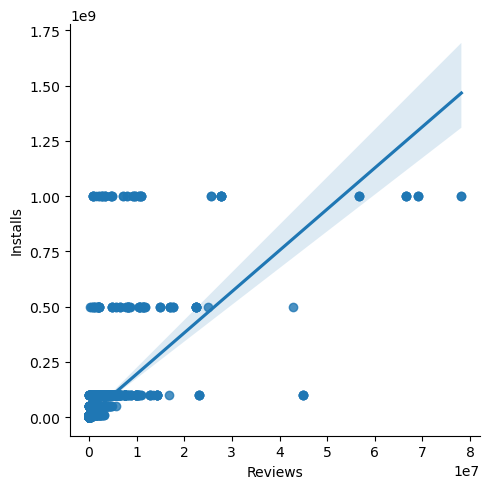

In [64]:
#  plot reviews and installs in a scatter plot with trend line
plt.figure(figsize=(16, 6)) # make figure size
sns.lmplot(x='Reviews', y='Installs', data=df) # plot the scatter plot with trend lin

Here, we can see a nice trend, which shows that number of Reviews increases with the number of Installs, which is quite obvious.

We can see that most of the null values from Rating column are no - Moderate Installation apps, which make sense that if the app has less installations, it has less Rating and review.

In [65]:
df.head()

,App,Category,Rating,Reviews,Size in mb,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_category
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,Moderate
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,High
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,Very High
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,Top Notch
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,More than moderate


In [66]:
df["Price"]

0        0
1        0
2        0
3        0
4        0
        ..
10519    0
10520    0
10521    0
10522    0
10523    0
Name: Price, Length: 10513, dtype: object

In [67]:
# df["Price"].astype(int) as $4.99 is the issue

In [68]:
df["Price"]=df["Price"].str.replace("$","")

In [69]:
df["Price"]=df["Price"].astype(float)

In [70]:

# using f string to print the min, max and average price of the apps
print(f"Min price is: {df['Price'].min()} $")
print(f"Max price is: {df['Price'].max()} $")
print(f"Average price is: {df['Price'].mean()} $")

Min price is: 0.0 $
Max price is: 400.0 $
Average price is: 1.0483867592504517 $


LAST UPDATED

In [71]:
df["Last Updated"]=pd.to_datetime(df["Last Updated"])
df["Last Updated"]

0       2018-01-07
1       2018-01-15
2       2018-08-01
3       2018-06-08
4       2018-06-20
           ...    
10519   2017-11-12
10520   2018-08-02
10521   2018-03-29
10522   2018-07-13
10523   2016-03-03
Name: Last Updated, Length: 10513, dtype: datetime64[ns]

CURRENT VAR

In [72]:
df.head(2)

,App,Category,Rating,Reviews,Size in mb,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_category
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,Moderate
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,High


In [73]:
# df["Current Ver"]=df["Current Ver"].str.replace(".","")
# df["Current Ver"].value_counts()
# df["Current Ver"].unique()

In [74]:
# non_int_un=[i for i in df["Current Ver"].unique() if type(i)!=int]
# int_un_non=[i for i in df["Current Ver"]if type(i)!=int]
# print(f"total non int values in 'CurrentVer_New' feature is {len(int_un_non)}")
# print(f"unique non int are",len(non_int_un))



ANDROID VERSION

In [75]:
df["Android Ver"].value_counts

<bound method IndexOpsMixin.value_counts of 0        4.0.3 and up
1        4.0.3 and up
2        4.0.3 and up
3          4.2 and up
4          4.4 and up
             ...     
10519      4.0 and up
10520      4.2 and up
10521      4.1 and up
10522      2.3 and up
10523      4.0 and up
Name: Android Ver, Length: 10513, dtype: object>

In [76]:
df.head()

,App,Category,Rating,Reviews,Size in mb,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_category
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,Moderate
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,High
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,Very High
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,Top Notch
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,More than moderate



Insights from Data

which category is highest?


In [77]:
df['Category'].value_counts().head(10) # this will show the top 10 categories with highest number of apps


Category
FAMILY             1921
GAME               1114
TOOLS               818
MEDICAL             458
BUSINESS            445
PRODUCTIVITY        415
PERSONALIZATION     375
COMMUNICATION       371
LIFESTYLE           362
FINANCE             356
Name: count, dtype: int64

which categiry has higehst number on installs

In [78]:
df.groupby("Category")["Installs"].sum().sort_values(ascending=False).head(10)

Category
GAME                  34991898254
COMMUNICATION         32645724321
PRODUCTIVITY          14175987704
SOCIAL                14059566802
TOOLS                 11438308805
FAMILY                10240755454
PHOTOGRAPHY            9967231655
NEWS_AND_MAGAZINES     7493872740
TRAVEL_AND_LOCAL       6868744046
VIDEO_PLAYERS          6122002620
Name: Installs, dtype: int64

whcih categoiry has hights number of reviews?

In [79]:
df.groupby("Category")["Reviews"].sum().sort_values(ascending=False).head(10)

Category
GAME               1582272719
COMMUNICATION       815414335
SOCIAL              621079801
FAMILY              409315182
TOOLS               272796344
PHOTOGRAPHY         211491555
SHOPPING            114943208
PRODUCTIVITY        114115838
VIDEO_PLAYERS       110325372
PERSONALIZATION      89191298
Name: Reviews, dtype: int64

Which categiry has highest rating?

In [80]:
df.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(10)

Category
EVENTS                 4.390323
EDUCATION              4.388462
ART_AND_DESIGN         4.373437
BOOKS_AND_REFERENCE    4.341315
PERSONALIZATION        4.340533
PARENTING              4.300000
GAME                   4.289228
HEALTH_AND_FITNESS     4.285207
BEAUTY                 4.283019
SHOPPING               4.263035
Name: Rating, dtype: float64

plotting the rating ki distribution

/tmp/ipykernel_8690/774399487.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['Rating'], color="blue", shade=True)


<Axes: xlabel='Rating', ylabel='Density'>

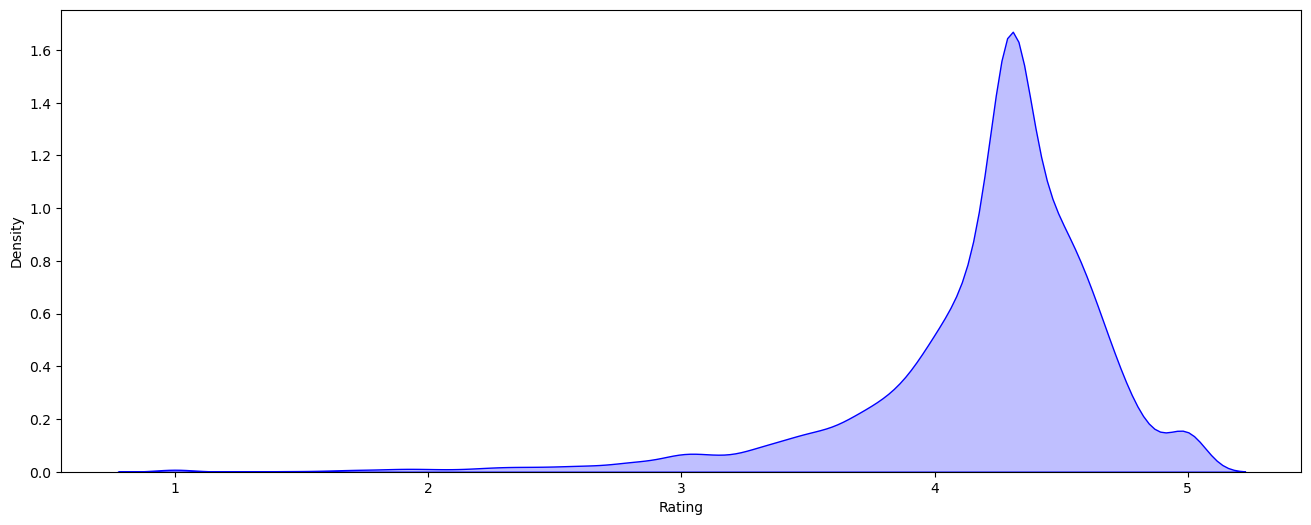

In [81]:

# plot the rating distribution
plt.figure(figsize=(16, 6)) # make figure size
sns.kdeplot(df['Rating'], color="blue", shade=True) 

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns


PLOTTING GRPAHS BETWEEN RATING INTSALLS SIZE OF CORR

In [83]:
plt.figure(figsize=(15,18))
cdf=df[['Rating','Installs','Size in mb']]
corr=cdf.corr()
corr



,Rating,Installs,Size in mb
Rating,1.000000,0.046263,0.015744
Installs,0.046263,1.000000,0.008507
Size in mb,0.015744,0.008507,1.000000


<Figure size 1500x1800 with 0 Axes>

<Axes: >

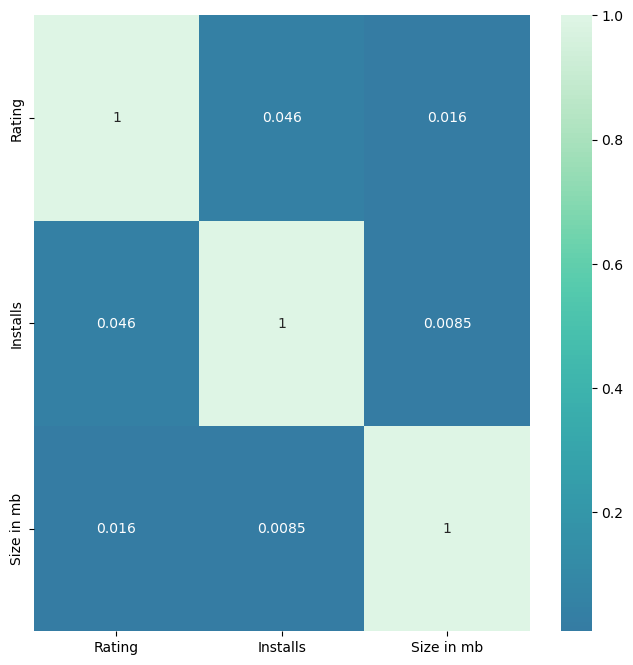

In [84]:
plt.figure(figsize=(8,8))
sns.heatmap(corr,annot=True,cmap='mako',center=0)

In [85]:
#findimg uniquee values in the rating
df["Rating"].unique()

array([4.1, 3.9, 4.7, 4.5, 4.3, 4.4, 3.8, 4.2, 4.6, 4. , 4.8, 4.9, 3.6,
       3.7, 3.2, 3.3, 3.4, 3.5, 3.1, 5. , 2.6, 3. , 1.9, 2.5, 2.8, 2.7,
       1. , 2.9, 2.3, 2.2, 1.7, 2. , 1.8, 2.4, 1.6, 2.1, 1.4, 1.5, 1.2])

In [86]:
#who has permission to see which content
df["Content Rating"].unique()

array(['Everyone', 'Teen', 'Everyone 10+', 'Mature 17+',
       'Adults only 18+', 'Unrated'], dtype=object)

In [87]:
df["Type"].hasnans

False

In [88]:
df["Type"].unique()

array(['Free', 'Paid'], dtype=object)

In [89]:
df[df["Type"].isna()]

,App,Category,Rating,Reviews,Size in mb,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_category


In [90]:
df[df["Type"].isna()].index

Index([], dtype='int64')

In [91]:
# df.drop(9148, inplace=True)
# df.reset_index(drop=True, inplace=True)



In [92]:
df["Type"].hasnans

False

VALUES COUNTS OF TYPES WHETHER PAID OR FREE

In [93]:
paid_df=df[df["Type"]=='Paid']
paid_df

,App,Category,Rating,Reviews,Size in mb,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_category
234,TurboScan: scan documents and receipts in PDF,BUSINESS,4.7,11442,0.0,100000,Paid,4.99,Everyone,Business,2018-03-25,1.5.2,4.0 and up,More than moderate
235,Tiny Scanner Pro: PDF Doc Scan,BUSINESS,4.8,10295,14.0,100000,Paid,4.99,Everyone,Business,2017-04-11,3.4.6,3.0 and up,More than moderate
290,TurboScan: scan documents and receipts in PDF,BUSINESS,4.7,11442,0.0,100000,Paid,4.99,Everyone,Business,2018-03-25,1.5.2,4.0 and up,More than moderate
291,Tiny Scanner Pro: PDF Doc Scan,BUSINESS,4.8,10295,35.0,100000,Paid,4.99,Everyone,Business,2017-04-11,3.4.6,3.0 and up,More than moderate
427,Puffin Browser Pro,COMMUNICATION,4.0,18247,14.0,100000,Paid,3.99,Everyone,Communication,2018-07-05,7.5.3.20547,4.1 and up,More than moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10453,"Talkie Pro - Wi-Fi Calling, Chats, File Sharing",COMMUNICATION,4.5,201,7.0,1000,Paid,2.99,Everyone,Communication,2018-01-06,Varies with device,Varies with device,Low
10457,WiFi Monitor Pro - analyzer of Wi-Fi networks,TOOLS,4.6,85,41.0,1000,Paid,2.99,Everyone,Tools,2018-07-05,1.9,4.0 and up,Low
10459,SCI-FI UI,FAMILY,4.7,15,3.9,100,Paid,1.99,Everyone,Entertainment,2018-04-16,0.0.53,1.6 and up,Low
10460,Wi-Fi Rabbit Unlock Key,TOOLS,4.5,142,8.9,5000,Paid,1.00,Everyone,Tools,2011-06-26,1.0.0,2.1 and up,Moderate


In [94]:
len(paid_df)# total number of paid categories

772

In [95]:
free_df=df[df["Type"]=="Free"]
free_df

,App,Category,Rating,Reviews,Size in mb,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_category
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,Moderate
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,High
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,Very High
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,Top Notch
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,More than moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10519,Driving Suv Toyota Car Simulator,FAMILY,3.7,187,53.0,10000,Free,0.0,Everyone,Simulation,2017-11-12,1,4.0 and up,Moderate
10520,Navy Gunner Shoot War 3D,GAME,4.0,103199,3.6,10000000,Free,0.0,Teen,Action,2018-08-02,1.0.7.8,4.2 and up,Very High
10521,Drift Legends,GAME,4.2,33788,9.5,1000000,Free,0.0,Everyone,Racing,2018-03-29,1.8.5,4.1 and up,High
10522,FK,MEDICAL,4.4,1517,0.0,100000,Free,0.0,Everyone,Medical,2018-07-13,2.5.9,2.3 and up,More than moderate


In [96]:
len(free_df)

9741

In [97]:
df["Type"].value_counts()

Type
Free    9741
Paid     772
Name: count, dtype: int64

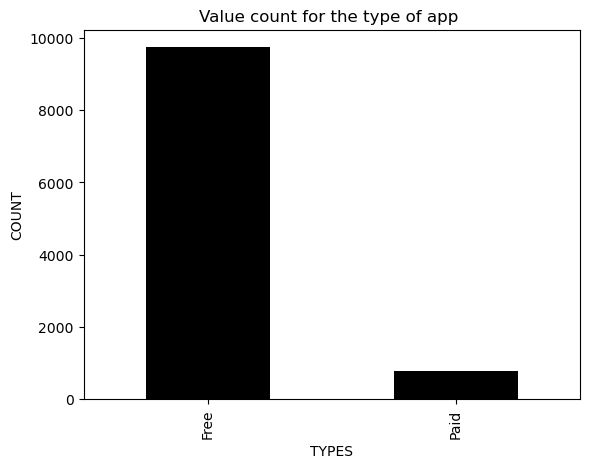

In [98]:
#graph for paid and free apps

df["Type"].value_counts().plot.bar(color="black")
plt.ylabel("COUNT")
plt.xlabel("TYPES")
plt.title("Value count for the type of app ")
plt.show()

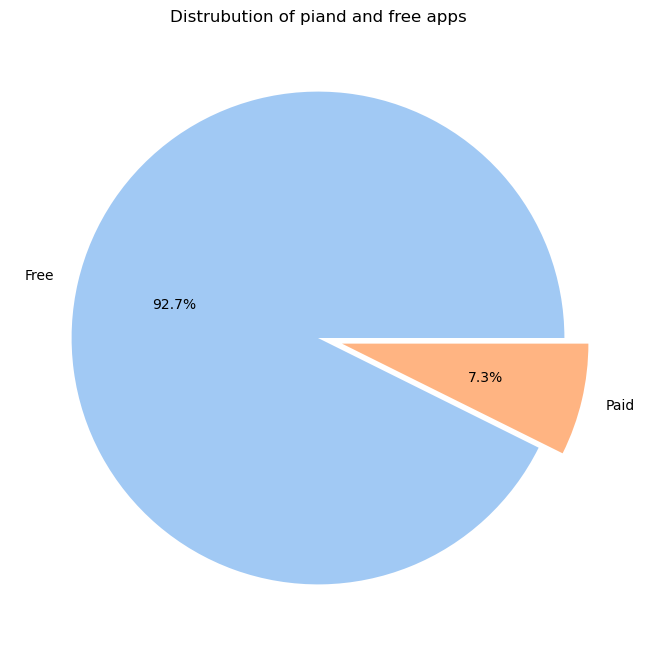

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns
app_type = df["Type"].value_counts()
explode = (0, 0.1)
plt.figure(figsize=(8,8))
colors = sns.color_palette("pastel")
plt.pie(app_type, labels=app_type.index, autopct='%1.1f%%', explode=explode, colors=colors)
plt.title("Distrubution of piand and free apps")
plt.show()


CONTENT RATING

In [100]:
df["Content Rating"]

0        Everyone
1        Everyone
2        Everyone
3            Teen
4        Everyone
           ...   
10519    Everyone
10520        Teen
10521    Everyone
10522    Everyone
10523    Everyone
Name: Content Rating, Length: 10513, dtype: object

In [101]:
df["Content Rating"].unique()

array(['Everyone', 'Teen', 'Everyone 10+', 'Mature 17+',
       'Adults only 18+', 'Unrated'], dtype=object)

In [102]:
df["Content Rating"].hasnans

False

(array([8.44e+03, 0.00e+00, 1.17e+03, 0.00e+00, 4.09e+02, 0.00e+00,
        4.89e+02, 0.00e+00, 3.00e+00, 2.00e+00]),
 array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. ]),
 <BarContainer object of 10 artists>)

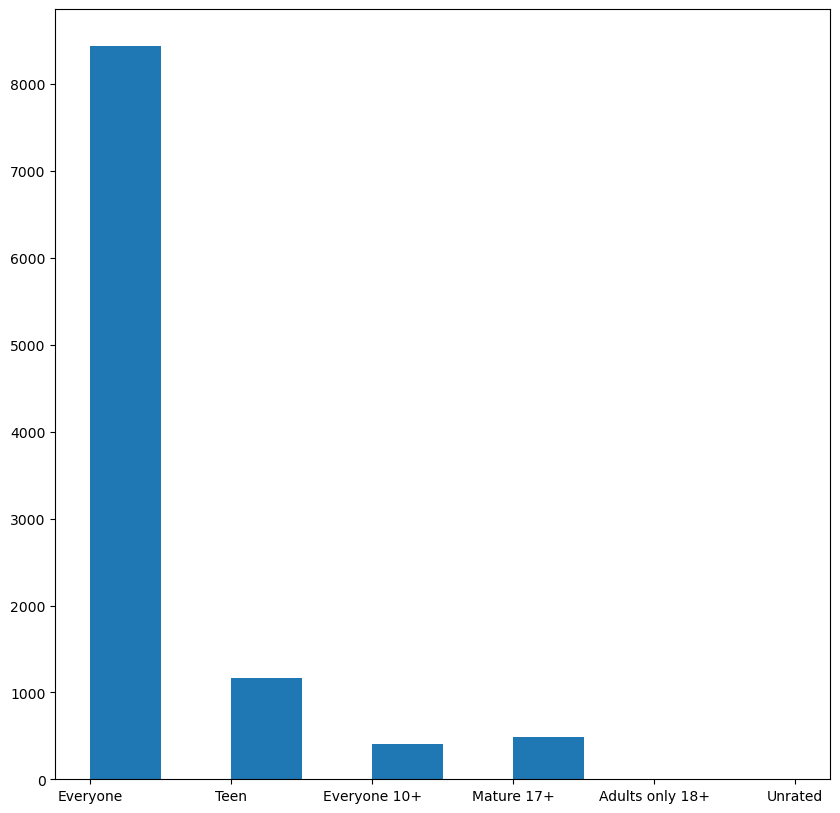

In [103]:
plt.figure(figsize=(10,10))
plt.hist(df["Content Rating"])

WORKING ON THE GRAPH OF CONTENT RATING respect ro installs

In [104]:
import pandas as pd
df_content_installs = pd.pivot_table(df, index="Content Rating", values=["Installs"])
df_content_installs_sorted = df_content_installs.sort_values(by="Installs", ascending=False)
top_10_content = df_content_installs_sorted.head(10)

print("Top 10 content rating  by Installs:",top_10_content)


Top 10 content rating  by Installs:                      Installs
Content Rating               
Everyone 10+     3.233206e+07
Teen             2.963611e+07
Everyone         1.348366e+07
Mature 17+       1.127452e+07
Adults only 18+  6.666667e+05
Unrated          2.525000e+04


<Axes: xlabel='Content Rating'>

<Figure size 6000x6000 with 0 Axes>

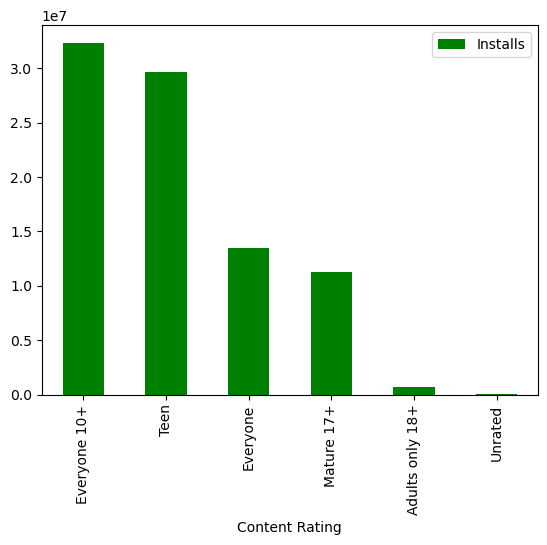

In [105]:
plt.figure(figsize=(60,60))
top_10_content.plot(kind="bar", color=['green'])

WORKING ON THE PRICE

In [106]:
df["Price"]

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
10519    0.0
10520    0.0
10521    0.0
10522    0.0
10523    0.0
Name: Price, Length: 10513, dtype: float64

FINDING THE MAXIMUM PRICE AND LOWEST


In [107]:
print("the maximum price of the app is",df["Price"].max())

the maximum price of the app is 400.0


In [108]:
df.loc[df["Price"].idxmax()]


App                  I'm Rich - Trump Edition
Category                            LIFESTYLE
Rating                                    3.6
Reviews                                   275
Size in mb                               71.0
Installs                                10000
Type                                     Paid
Price                                   400.0
Content Rating                       Everyone
Genres                              Lifestyle
Last Updated              2018-05-03 00:00:00
Current Ver                             1.0.1
Android Ver                        4.1 and up
Installs_category                    Moderate
Name: 4367, dtype: object

In [109]:
pdf=df.sort_values("Price",ascending=False)
pdf

,App,Category,Rating,Reviews,Size in mb,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_category
4367,I'm Rich - Trump Edition,LIFESTYLE,3.6,275,71.0,10000,Paid,400.00,Everyone,Lifestyle,2018-05-03,1.0.1,4.1 and up,Moderate
5354,I am Rich Plus,FAMILY,4.0,856,88.0,10000,Paid,399.99,Everyone,Entertainment,2018-05-19,3.0,4.4 and up,Moderate
9934,I'm Rich/Eu sou Rico/أنا غني/我很有錢,LIFESTYLE,4.3,0,1.5,0,Paid,399.99,Everyone,Lifestyle,2017-12-01,MONEY,4.1 and up,no
5373,I AM RICH PRO PLUS,FINANCE,4.0,36,2.1,1000,Paid,399.99,Everyone,Finance,2018-06-25,1.0.2,4.1 and up,Low
5364,I am rich (Most expensive app),FINANCE,4.1,129,0.0,1000,Paid,399.99,Teen,Finance,2017-12-06,2,4.0.3 and up,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10508,PIP Selfie Camera Photo Editor,PHOTOGRAPHY,4.4,156322,2.9,10000000,Free,0.00,Everyone,Photography,2018-02-01,Varies with device,Varies with device,Very High
10507,Drive 4x4 Luxury SUV Jeep,GAME,4.2,2183,3.1,500000,Free,0.00,Everyone,Racing,2018-07-10,1.12,2.3 and up,High
16,Photo Designer - Write your name with shapes,ART_AND_DESIGN,4.7,3632,5.5,500000,Free,0.00,Everyone,Art & Design,2018-07-31,3.1,4.1 and up,High
14,3D Color Pixel by Number - Sandbox Art Coloring,ART_AND_DESIGN,4.4,1518,37.0,100000,Free,0.00,Everyone,Art & Design,2018-08-03,1.2.3,2.3 and up,More than moderate


In [110]:
#The highgetst paid category is
df.loc[4367,["Category","App","Installs"]].to_frame()


,4367
Category,LIFESTYLE
App,I'm Rich - Trump Edition
Installs,10000


In [111]:
print(f"the lowest prices are{df['Price'].min()}")

the lowest prices are0.0


In [112]:
zdf=df[df["Price"]==0]
zdf

,App,Category,Rating,Reviews,Size in mb,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_category
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,Moderate
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,High
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,Very High
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,Top Notch
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,More than moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10519,Driving Suv Toyota Car Simulator,FAMILY,3.7,187,53.0,10000,Free,0.0,Everyone,Simulation,2017-11-12,1,4.0 and up,Moderate
10520,Navy Gunner Shoot War 3D,GAME,4.0,103199,3.6,10000000,Free,0.0,Teen,Action,2018-08-02,1.0.7.8,4.2 and up,Very High
10521,Drift Legends,GAME,4.2,33788,9.5,1000000,Free,0.0,Everyone,Racing,2018-03-29,1.8.5,4.1 and up,High
10522,FK,MEDICAL,4.4,1517,0.0,100000,Free,0.0,Everyone,Medical,2018-07-13,2.5.9,2.3 and up,More than moderate


In [113]:
# with 0 price max number of installs 
sorted_installs=zdf.sort_values("Installs",ascending=False)
sorted_installs

,App,Category,Rating,Reviews,Size in mb,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_category
3523,Google Drive,PRODUCTIVITY,4.4,2731211,0.0,1000000000,Free,0.0,Everyone,Productivity,2018-08-06,Varies with device,Varies with device,Top Notch
5395,Google Photos,PHOTOGRAPHY,4.5,10847682,25.0,1000000000,Free,0.0,Everyone,Photography,2018-08-01,Varies with device,Varies with device,Top Notch
4104,Messenger – Text and Video Chat for Free,COMMUNICATION,4.0,56642847,1.7,1000000000,Free,0.0,Everyone,Communication,2018-08-01,Varies with device,Varies with device,Top Notch
3223,Maps - Navigate & Explore,TRAVEL_AND_LOCAL,4.3,9235373,0.0,1000000000,Free,0.0,Everyone,Travel & Local,2018-07-31,Varies with device,Varies with device,Top Notch
3232,Google Street View,TRAVEL_AND_LOCAL,4.2,2129707,17.0,1000000000,Free,0.0,Everyone,Travel & Local,2018-08-06,Varies with device,Varies with device,Top Notch
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4550,RMEduS - 음성인식을 활용한 R 프로그래밍 실습 시스템,FAMILY,4.3,4,19.0,1,Free,0.0,Everyone,Education,2018-07-17,1.0.1,4.4 and up,Very low
7434,Pekalongan CJ,SOCIAL,4.3,0,74.0,0,Free,0.0,Teen,Social,2018-07-21,0.0.1,4.4 and up,no
8081,CX Network,BUSINESS,4.3,0,5.8,0,Free,0.0,Everyone,Business,2018-08-06,1.3.1,4.1 and up,no
8871,Test Application DT 02,ART_AND_DESIGN,4.3,0,2.8,0,Free,0.0,Everyone,Art & Design,2017-03-14,4.0,4.2 and up,no


In [114]:
len(zdf["App"])

9741

In [115]:

# print the number of duplicates in df
print(f"Number of duplicates in df are: {df.duplicated().sum()}")

Number of duplicates in df are: 82


In [116]:
# find exact duplicates and print them
df[df['App'].duplicated(keep=False)].sort_values(by='App')

,App,Category,Rating,Reviews,Size in mb,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_category
1407,10 Best Foods for You,HEALTH_AND_FITNESS,4.0,2490,58.0,500000,Free,0.00,Everyone 10+,Health & Fitness,2017-02-17,1.9,2.3.3 and up,High
1393,10 Best Foods for You,HEALTH_AND_FITNESS,4.0,2490,0.0,500000,Free,0.00,Everyone 10+,Health & Fitness,2017-02-17,1.9,2.3.3 and up,High
2543,1800 Contacts - Lens Store,MEDICAL,4.7,23160,31.0,1000000,Free,0.00,Everyone,Medical,2018-07-27,7.4.1,5.0 and up,High
2322,1800 Contacts - Lens Store,MEDICAL,4.7,23160,30.0,1000000,Free,0.00,Everyone,Medical,2018-07-27,7.4.1,5.0 and up,High
2385,2017 EMRA Antibiotic Guide,MEDICAL,4.4,12,41.0,1000,Paid,16.99,Everyone,Medical,2017-01-27,1.0.5,4.0.3 and up,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3103,trivago: Hotels & Travel,TRAVEL_AND_LOCAL,4.2,219848,0.0,50000000,Free,0.00,Everyone,Travel & Local,2018-08-02,Varies with device,Varies with device,Top Notch
3118,trivago: Hotels & Travel,TRAVEL_AND_LOCAL,4.2,219848,86.0,50000000,Free,0.00,Everyone,Travel & Local,2018-08-02,Varies with device,Varies with device,Top Notch
3202,trivago: Hotels & Travel,TRAVEL_AND_LOCAL,4.2,219848,8.5,50000000,Free,0.00,Everyone,Travel & Local,2018-08-02,Varies with device,Varies with device,Top Notch
8291,wetter.com - Weather and Radar,WEATHER,4.2,189310,2.5,10000000,Free,0.00,Everyone,Weather,2018-08-06,Varies with device,Varies with device,Very High


In [117]:
df[df['App'].duplicated(keep=False)].sort_values(by='App')

,App,Category,Rating,Reviews,Size in mb,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_category
1407,10 Best Foods for You,HEALTH_AND_FITNESS,4.0,2490,58.0,500000,Free,0.00,Everyone 10+,Health & Fitness,2017-02-17,1.9,2.3.3 and up,High
1393,10 Best Foods for You,HEALTH_AND_FITNESS,4.0,2490,0.0,500000,Free,0.00,Everyone 10+,Health & Fitness,2017-02-17,1.9,2.3.3 and up,High
2543,1800 Contacts - Lens Store,MEDICAL,4.7,23160,31.0,1000000,Free,0.00,Everyone,Medical,2018-07-27,7.4.1,5.0 and up,High
2322,1800 Contacts - Lens Store,MEDICAL,4.7,23160,30.0,1000000,Free,0.00,Everyone,Medical,2018-07-27,7.4.1,5.0 and up,High
2385,2017 EMRA Antibiotic Guide,MEDICAL,4.4,12,41.0,1000,Paid,16.99,Everyone,Medical,2017-01-27,1.0.5,4.0.3 and up,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3103,trivago: Hotels & Travel,TRAVEL_AND_LOCAL,4.2,219848,0.0,50000000,Free,0.00,Everyone,Travel & Local,2018-08-02,Varies with device,Varies with device,Top Notch
3118,trivago: Hotels & Travel,TRAVEL_AND_LOCAL,4.2,219848,86.0,50000000,Free,0.00,Everyone,Travel & Local,2018-08-02,Varies with device,Varies with device,Top Notch
3202,trivago: Hotels & Travel,TRAVEL_AND_LOCAL,4.2,219848,8.5,50000000,Free,0.00,Everyone,Travel & Local,2018-08-02,Varies with device,Varies with device,Top Notch
8291,wetter.com - Weather and Radar,WEATHER,4.2,189310,2.5,10000000,Free,0.00,Everyone,Weather,2018-08-06,Varies with device,Varies with device,Very High


In [118]:

# remove the duplicates
df.drop_duplicates(inplace=True)


In [119]:

# print the number of rows and columns after removing duplicates
print(f"Number of rows after removing duplicates: {df.shape[0]}")

Number of rows after removing duplicates: 10431


In [120]:
#the average price rating
print(f"The avg price of an app is{df['Price'].mean()}")

The avg price of an app is1.0551931741923115


In [121]:
df.describe()

,Rating,Reviews,Size in mb,Installs,Price,Last Updated
count,10431.000000,1.043100e+04,10431.000000,1.043100e+04,10431.000000,10431
mean,4.206059,4.565217e+05,18.874930,1.557975e+07,1.055193,2017-11-23 13:28:33.546160384
min,1.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,2010-05-21 00:00:00
25%,4.100000,4.100000e+01,3.000000,5.000000e+03,0.000000,2017-09-20 00:00:00
50%,4.300000,2.295000e+03,9.900000,1.000000e+05,0.000000,2018-05-24 00:00:00
75%,4.500000,5.727300e+04,26.000000,5.000000e+06,0.000000,2018-07-20 00:00:00
max,5.000000,7.815831e+07,1000.000000,1.000000e+09,400.000000,2018-08-08 00:00:00
std,0.481510,2.979084e+06,24.295979,8.472222e+07,16.256228,NaN


In [122]:
plt.figure(figsize=(15,18))
cdf=df[['Rating','Installs','Size in mb','Price']]
corr=cdf.corr()
corr


,Rating,Installs,Size in mb,Price
Rating,1.000000,0.047572,0.016464,-0.019640
Installs,0.047572,1.000000,0.011987,-0.011911
Size in mb,0.016464,0.011987,1.000000,0.036825
Price,-0.019640,-0.011911,0.036825,1.000000


<Figure size 1500x1800 with 0 Axes>

<Axes: >

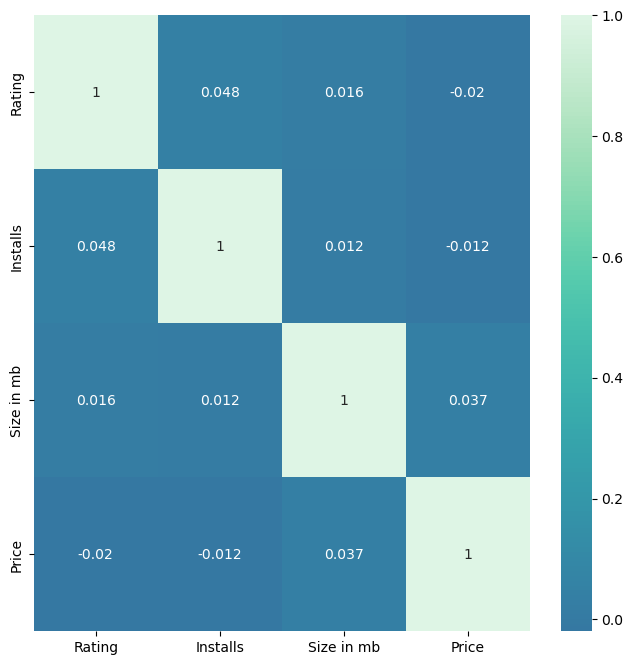

In [123]:
plt.figure(figsize=(8,8))
sns.heatmap(corr,cmap="mako",annot=True,center=0)

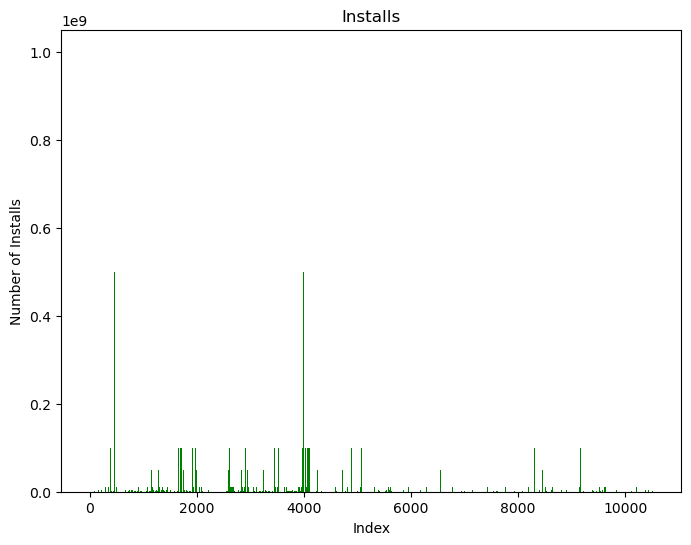

In [124]:

cdf=df[['Rating','Installs','Size in mb','Price']]# Plot for Installs
plt.figure(figsize=(8, 6))
plt.bar(df.index, df['Installs'], color='green')
plt.title('Installs')
plt.xlabel('Index')
plt.ylabel('Number of Installs')
plt.show()


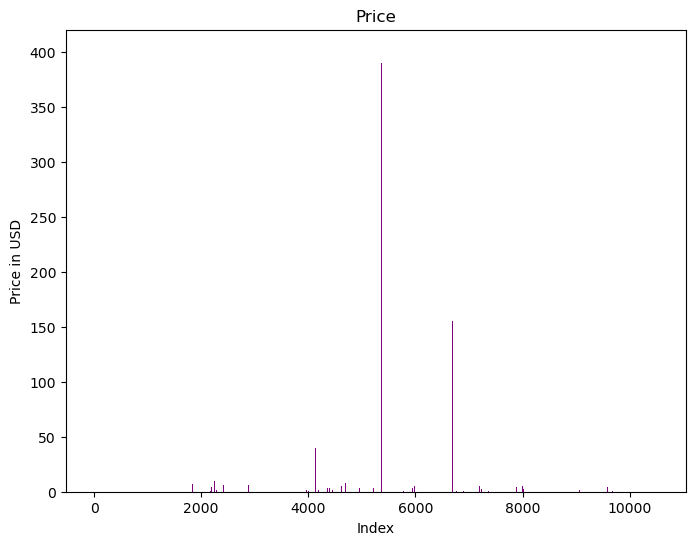

In [125]:
# Plot for Price
plt.figure(figsize=(8, 6))
plt.bar(df.index, df['Price'], color='purple')
plt.title('Price')
plt.xlabel('Index')
plt.ylabel('Price in USD')
plt.show()

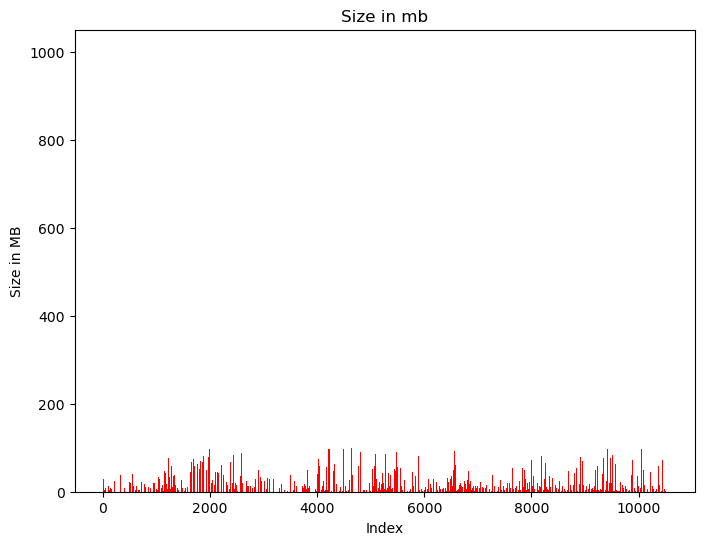

In [126]:
import matplotlib.pyplot as plt
# Plot for Size in mb
plt.figure(figsize=(8, 6))
plt.bar(df.index, df['Size in mb'], color='red')
plt.title('Size in mb')
plt.xlabel('Index')
plt.ylabel('Size in MB')
plt.show()

<Figure size 500x500 with 0 Axes>

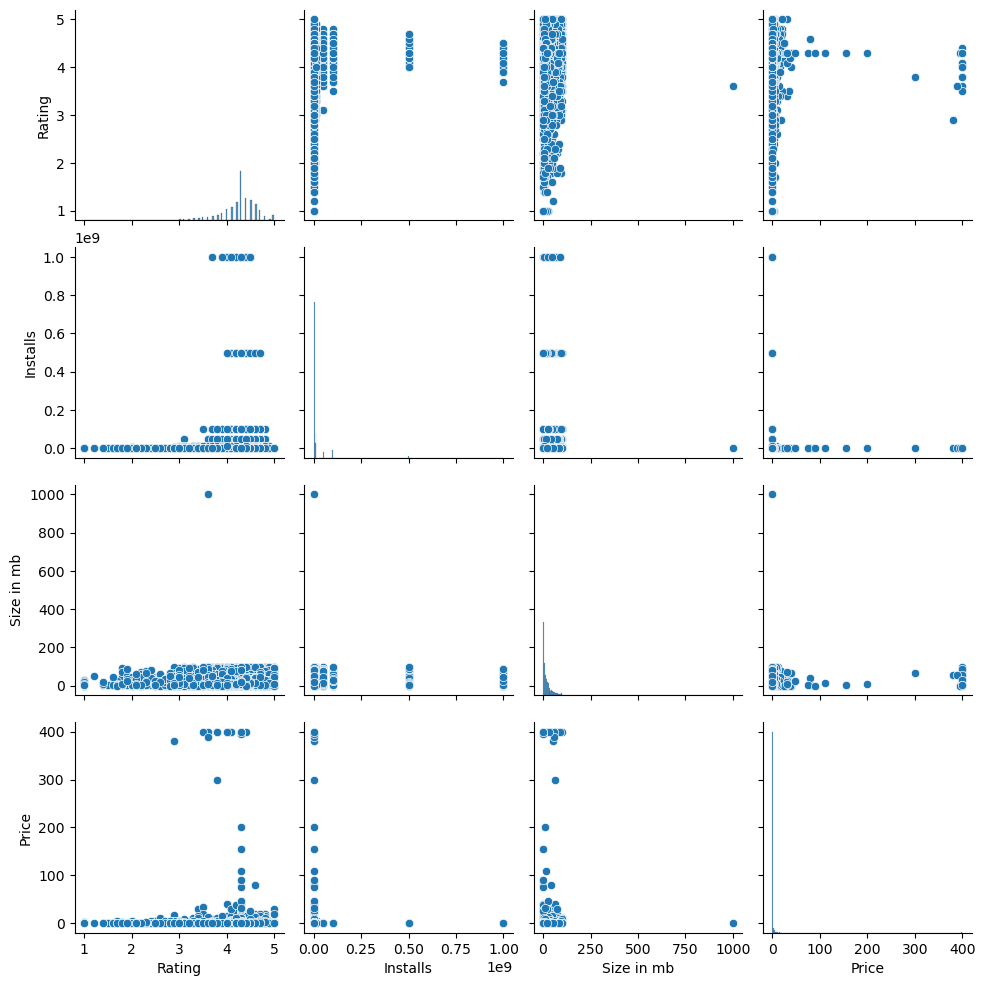

In [127]:
import seaborn as sns
plt.figure(figsize=(5,5))
pairplot=sns.pairplot(df[['Rating', 'Installs', 'Size in mb', 'Price']])
for ax in pairplot.axes.flatten():
    ax.set_facecolor('none')
plt.show()



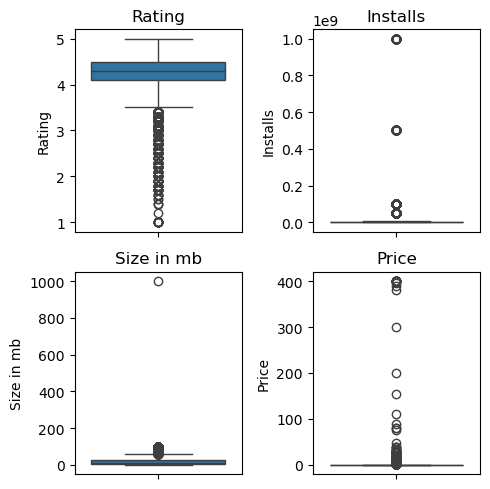

In [128]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))

# Create box plots
plt.subplot(2, 2, 1)
sns.boxplot(data=df['Rating'])
plt.title('Rating')

plt.subplot(2, 2, 2)
sns.boxplot(data=df['Installs'])
plt.title('Installs')

plt.subplot(2, 2, 3)
sns.boxplot(data=df['Size in mb'])
plt.title('Size in mb')

plt.subplot(2, 2, 4)
sns.boxplot(data=df['Price'])
plt.title('Price')

plt.tight_layout()
plt.show()


In [129]:
import streamlit as st
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Create a subplot grid
fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=('Rating', 'Installs', 'Size in mb', 'Price'),
    vertical_spacing=0.2,  # Adjust spacing between rows
    horizontal_spacing=0.1  # Adjust spacing between columns
)

# Add box plots to the subplots
fig.add_trace(go.Box(y=df['Rating'], name='Rating'), row=1, col=1)
fig.add_trace(go.Box(y=df['Installs'], name='Installs'), row=1, col=2)
fig.add_trace(go.Box(y=df['Size in mb'], name='Size in mb'), row=2, col=1)
fig.add_trace(go.Box(y=df['Price'], name='Price'), row=2, col=2)
fig.add_trace(go.Box(y=df['Reviews'], name='Reviews'),row=3,col=1)


# Update layout
fig.update_layout(
    title_text="Box Plots of Various Features",
    height=600,  # Adjust the height as needed
    showlegend=False
)

# Display the Plotly figure in Streamlit
# st.plotly_chart(fig)
fig.show()


In [130]:
df["Reviews"]

0           159
1           967
2         87510
3        215644
4           967
          ...  
10519       187
10520    103199
10521     33788
10522      1517
10523         2
Name: Reviews, Length: 10431, dtype: int64

Text(0.5, 1.0, 'Box plots for Reviews')

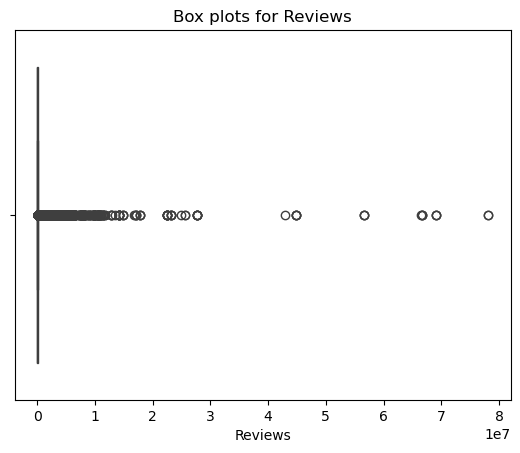

In [131]:

y=sns.boxplot(x=df["Reviews"])
y.set_title("Box plots for Reviews")


<Axes: >

<Figure size 1500x1800 with 0 Axes>

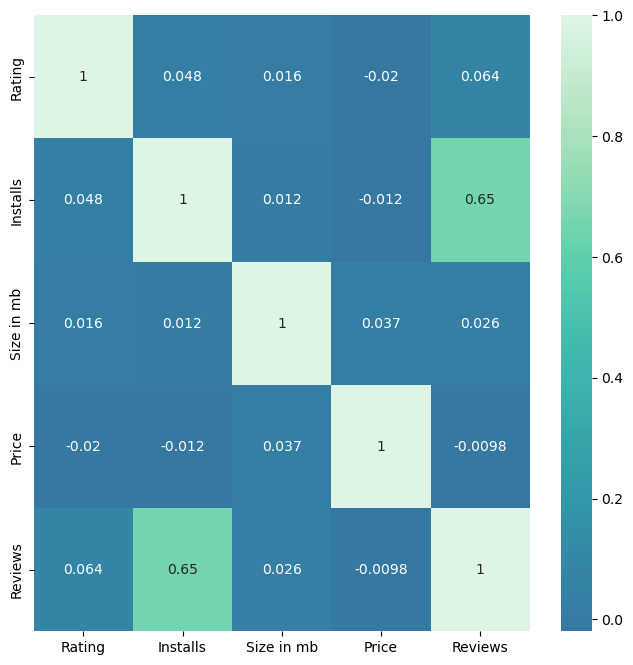

In [132]:
plt.figure(figsize=(15,18))
cdf=df[['Rating','Installs','Size in mb','Price',"Reviews"]]
corr=cdf.corr()
corr



plt.figure(figsize=(8,8))
sns.heatmap(corr,annot=True,cmap="mako",center=0)

REVIEWS AND INSTALLS HAVE HIGGHETS CORELATION

In [133]:
df.describe()

,Rating,Reviews,Size in mb,Installs,Price,Last Updated
count,10431.000000,1.043100e+04,10431.000000,1.043100e+04,10431.000000,10431
mean,4.206059,4.565217e+05,18.874930,1.557975e+07,1.055193,2017-11-23 13:28:33.546160384
min,1.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,2010-05-21 00:00:00
25%,4.100000,4.100000e+01,3.000000,5.000000e+03,0.000000,2017-09-20 00:00:00
50%,4.300000,2.295000e+03,9.900000,1.000000e+05,0.000000,2018-05-24 00:00:00
75%,4.500000,5.727300e+04,26.000000,5.000000e+06,0.000000,2018-07-20 00:00:00
max,5.000000,7.815831e+07,1000.000000,1.000000e+09,400.000000,2018-08-08 00:00:00
std,0.481510,2.979084e+06,24.295979,8.472222e+07,16.256228,NaN


TOP 10 GENRES BY INSTALLS

In [134]:
df.head()

,App,Category,Rating,Reviews,Size in mb,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_category
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,Moderate
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,High
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,Very High
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,Top Notch
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,More than moderate


In [135]:
# # print the number of rows and columns after removing duplicates
# print(f"Number of rows after removing duplicates: {df.shape[0]}")


In [136]:
import pandas as pd
df_genres_installs = pd.pivot_table(df, index="Genres", values=["Installs"])
df_genres_installs_sorted = df_genres_installs.sort_values(by="Installs", ascending=False)
top_10_genres = df_genres_installs_sorted.head(10)

print("Top 10 Genres by Installs:")
print(top_10_genres)


Top 10 Genres by Installs:
                                  Installs
Genres                                    
Communication                 8.545034e+07
Adventure;Action & Adventure  6.970385e+07
Casual                        5.085689e+07
Arcade                        5.012163e+07
Social                        4.863961e+07
Video Players & Editors       3.571347e+07
Productivity                  3.182606e+07
Puzzle;Action & Adventure     3.102000e+07
Photography                   3.054059e+07
Travel & Local                2.850479e+07


<Axes: xlabel='Genres'>

<Figure size 6000x6000 with 0 Axes>

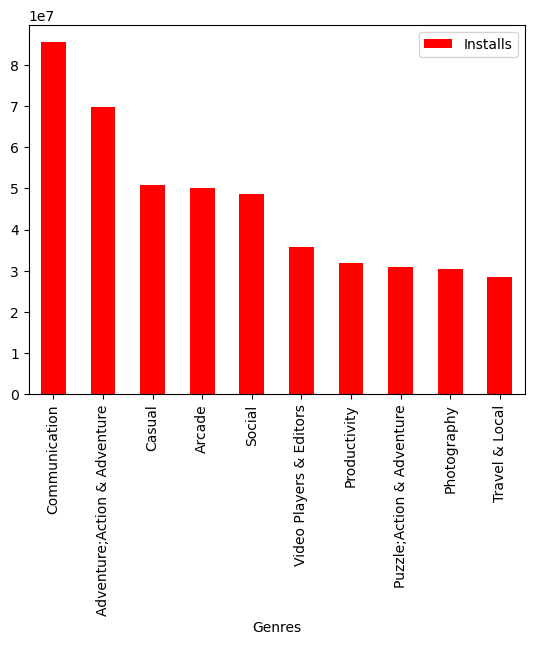

In [137]:
plt.figure(figsize=(60,60))
top_10_genres.plot(kind="bar",stacked=True, color=['red'])

<Axes: ylabel='Genres'>

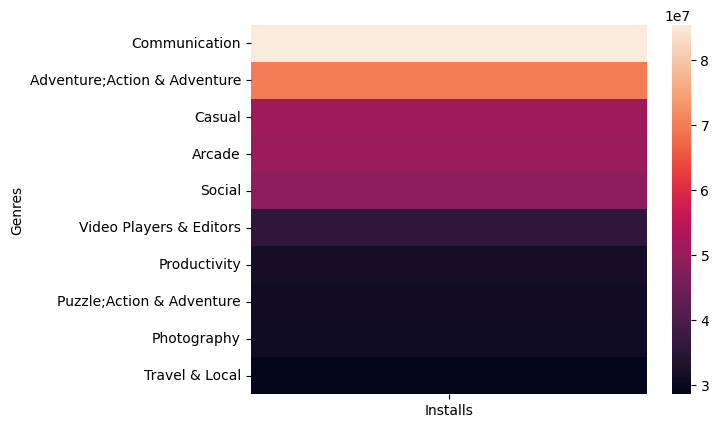

In [138]:
sns.heatmap(top_10_genres)

In [139]:
df.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10) #pendinng insights and work on category

Category
GAME                  34991898254
COMMUNICATION         31445724321
SOCIAL                13959566802
PRODUCTIVITY          13175987704
TOOLS                 11438308805
FAMILY                10240705454
PHOTOGRAPHY            9956231655
TRAVEL_AND_LOCAL       6812744046
VIDEO_PLAYERS          6122002620
NEWS_AND_MAGAZINES     5463772740
Name: Installs, dtype: int64

PLOTTING GRAPH WITH SIZE GROUP BY INSTLLS

In [140]:
df["Current Ver"]

0                     1.0.0
1                     2.0.0
2                     1.2.4
3        Varies with device
4                       1.1
                ...        
10519                     1
10520               1.0.7.8
10521                 1.8.5
10522                 2.5.9
10523                   1.0
Name: Current Ver, Length: 10431, dtype: object

In [141]:
df["Last Updated"]

0       2018-01-07
1       2018-01-15
2       2018-08-01
3       2018-06-08
4       2018-06-20
           ...    
10519   2017-11-12
10520   2018-08-02
10521   2018-03-29
10522   2018-07-13
10523   2016-03-03
Name: Last Updated, Length: 10431, dtype: datetime64[ns]

In [142]:
df['Last Updated']=pd.to_datetime(df['Last Updated'])
df

,App,Category,Rating,Reviews,Size in mb,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_category
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,Moderate
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,High
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,Very High
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,Top Notch
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,More than moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10519,Driving Suv Toyota Car Simulator,FAMILY,3.7,187,53.0,10000,Free,0.0,Everyone,Simulation,2017-11-12,1,4.0 and up,Moderate
10520,Navy Gunner Shoot War 3D,GAME,4.0,103199,3.6,10000000,Free,0.0,Teen,Action,2018-08-02,1.0.7.8,4.2 and up,Very High
10521,Drift Legends,GAME,4.2,33788,9.5,1000000,Free,0.0,Everyone,Racing,2018-03-29,1.8.5,4.1 and up,High
10522,FK,MEDICAL,4.4,1517,0.0,100000,Free,0.0,Everyone,Medical,2018-07-13,2.5.9,2.3 and up,More than moderate


plot the no of installs for paid and free app

<Axes: xlabel='Type', ylabel='Installs'>

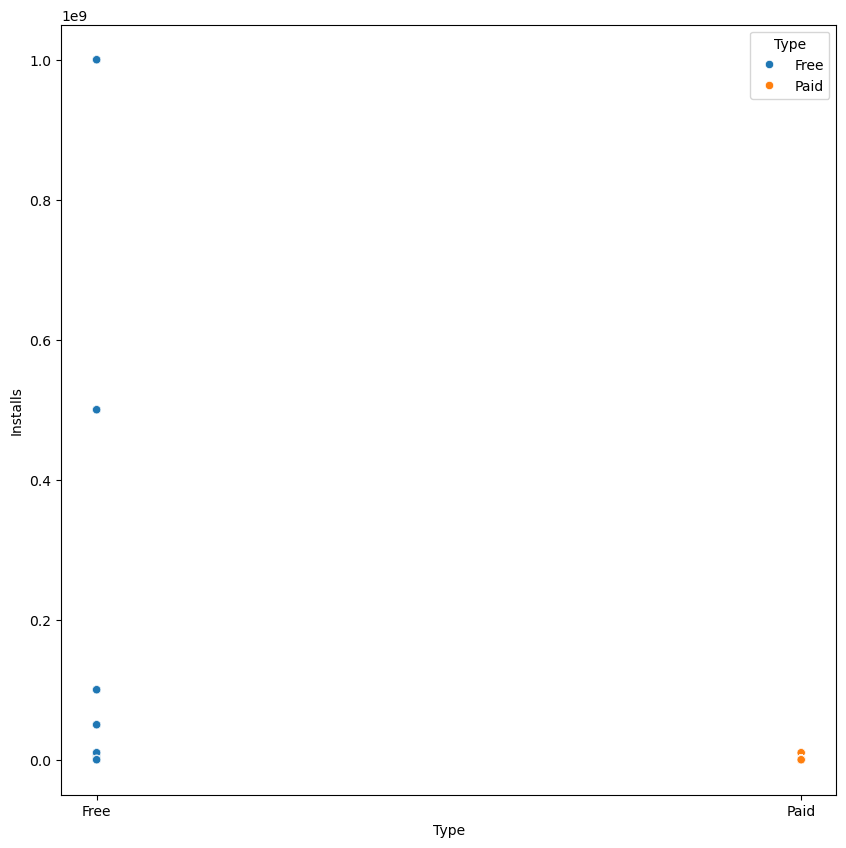

In [143]:
plt.figure(figsize=(10,10))
sns.scatterplot(x="Type",y="Installs",hue="Type",data=df)

<Axes: xlabel='Type', ylabel='Installs'>

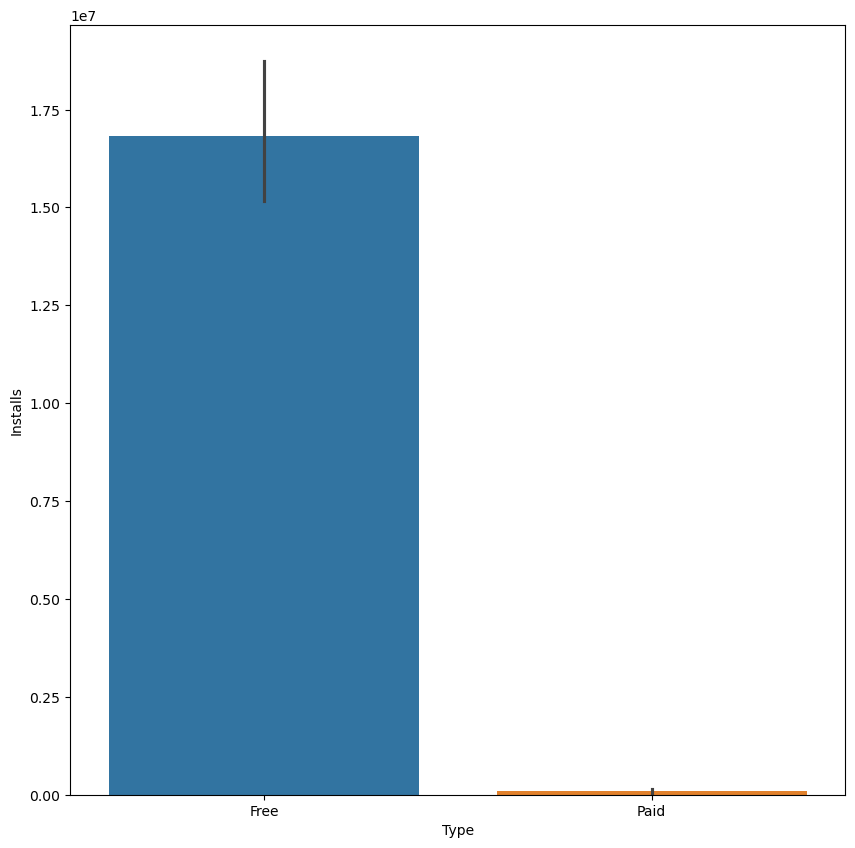

In [144]:
plt.figure(figsize=(10,10))
sns.barplot(x="Type",y="Installs",hue="Type",data=df)

effect on installs

/tmp/ipykernel_8690/2356022479.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




<Axes: xlabel='Installs_category', ylabel='Size in mb'>

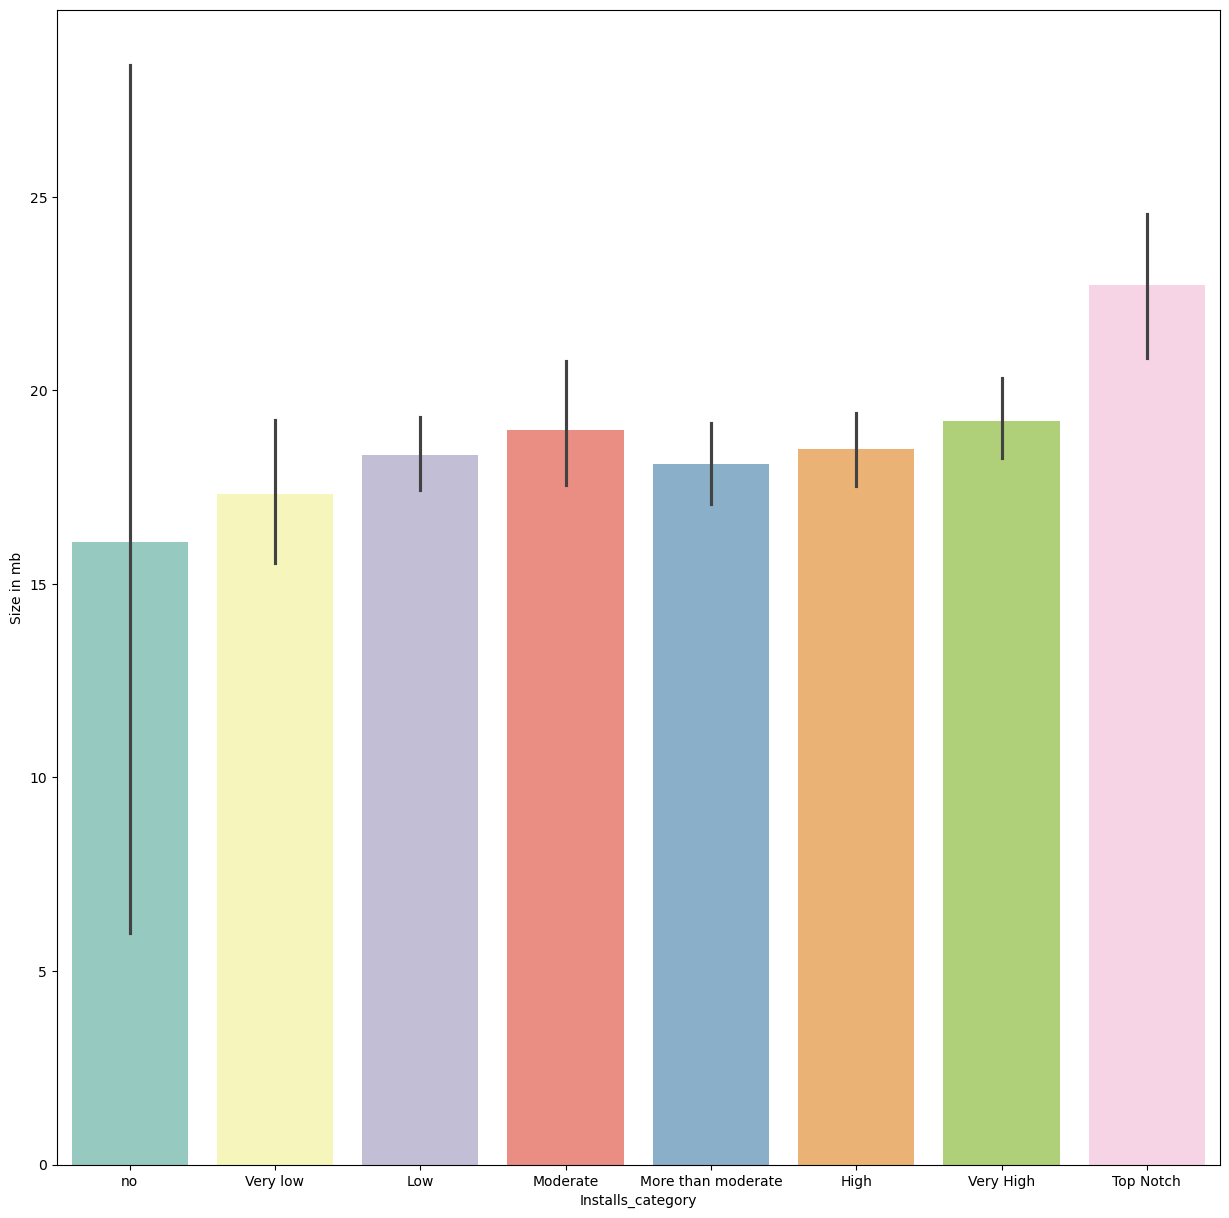

In [145]:
plt.figure(figsize=(15,15))
sns.barplot(x="Installs_category",y="Size in mb",data=df,palette="Set3")


Which content rating is most populare in installs?

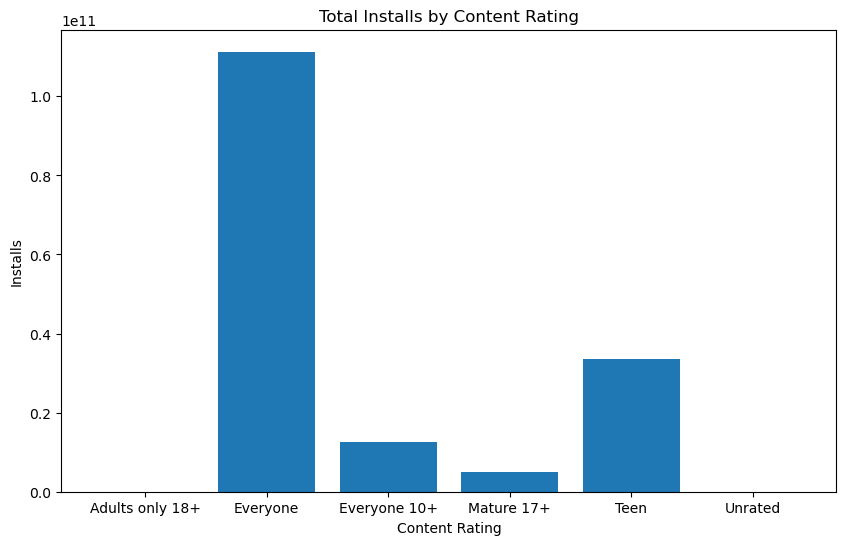

Most popular content rating in terms of installs:
Content Rating        Everyone
Installs          111283671229
Name: 1, dtype: object


In [146]:
content_rating_popularity = df.groupby('Content Rating')['Installs'].sum().reset_index()

plt.figure(figsize=(10, 6))
plt.bar(content_rating_popularity['Content Rating'], content_rating_popularity['Installs'])
plt.xlabel('Content Rating')
plt.ylabel('Installs')
plt.title('Total Installs by Content Rating')
plt.show()


most_popular_content_rating = content_rating_popularity.loc[content_rating_popularity['Installs'].idxmax()]
print("Most popular content rating in terms of installs:")
print(most_popular_content_rating)

In [147]:
import plotly.express as px
import pandas as pd

fig = px.scatter(df, x="Content Rating", y="Installs", size="Reviews", color="Category",
                 hover_name="App", size_max=60)

# Show the plot
fig.show()

In [148]:
df.tail()

,App,Category,Rating,Reviews,Size in mb,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_category
10519,Driving Suv Toyota Car Simulator,FAMILY,3.7,187,53.0,10000,Free,0.0,Everyone,Simulation,2017-11-12,1,4.0 and up,Moderate
10520,Navy Gunner Shoot War 3D,GAME,4.0,103199,3.6,10000000,Free,0.0,Teen,Action,2018-08-02,1.0.7.8,4.2 and up,Very High
10521,Drift Legends,GAME,4.2,33788,9.5,1000000,Free,0.0,Everyone,Racing,2018-03-29,1.8.5,4.1 and up,High
10522,FK,MEDICAL,4.4,1517,0.0,100000,Free,0.0,Everyone,Medical,2018-07-13,2.5.9,2.3 and up,More than moderate
10523,FK (FlightKid),GAME,4.3,2,19.0,10,Free,0.0,Everyone,Action,2016-03-03,1.0,4.0 and up,Very low


How many apps are there in content rating of everyone?

In [149]:
df["Category"].loc[df["Content Rating"]=="Everyone"].value_counts()

Category
FAMILY                 1493
TOOLS                   810
GAME                    594
MEDICAL                 435
BUSINESS                406
PRODUCTIVITY            404
FINANCE                 350
COMMUNICATION           328
LIFESTYLE               325
PHOTOGRAPHY             309
PERSONALIZATION         309
HEALTH_AND_FITNESS      301
SPORTS                  290
TRAVEL_AND_LOCAL        233
SHOPPING                200
BOOKS_AND_REFERENCE     186
NEWS_AND_MAGAZINES      158
VIDEO_PLAYERS           144
EDUCATION               141
MAPS_AND_NAVIGATION     128
FOOD_AND_DRINK          117
SOCIAL                   99
HOUSE_AND_HOME           85
LIBRARIES_AND_DEMO       83
AUTO_AND_VEHICLES        81
WEATHER                  71
ART_AND_DESIGN           60
PARENTING                58
EVENTS                   51
BEAUTY                   45
ENTERTAINMENT            39
COMICS                   25
DATING                   21
Name: count, dtype: int64

top 5 rated paid apps

In [150]:
df[df['Type'] == 'Paid'].sort_values(by='Rating', ascending=False).head(5)

,App,Category,Rating,Reviews,Size in mb,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_category
4477,Android P Style Icon Pack,PERSONALIZATION,5.0,1,3.1,100,Paid,0.99,Everyone,Personalization,2018-06-16,1.0,4.1 and up,Low
9056,Santa's Monster Shootout DX,GAME,5.0,4,31.0,50,Paid,1.99,Teen,Action,2013-08-15,1.05,2.2 and up,Low
5237,Hey AJ! It's Saturday!,BOOKS_AND_REFERENCE,5.0,12,18.0,100,Paid,3.99,Everyone,Books & Reference,2016-06-13,1.0.0,2.2 and up,Low
5246,Hey AJ! It's Bedtime!,FAMILY,5.0,1,40.0,10,Paid,4.99,Everyone,Education,2018-04-04,1.0.59,2.3 and up,Very low
5260,AJ Gray Dark Icon Pack,PERSONALIZATION,5.0,2,0.0,10,Paid,0.99,Everyone,Personalization,2018-04-29,1.1,4.1 and up,Very low


<Axes: xlabel='App', ylabel='Rating'>

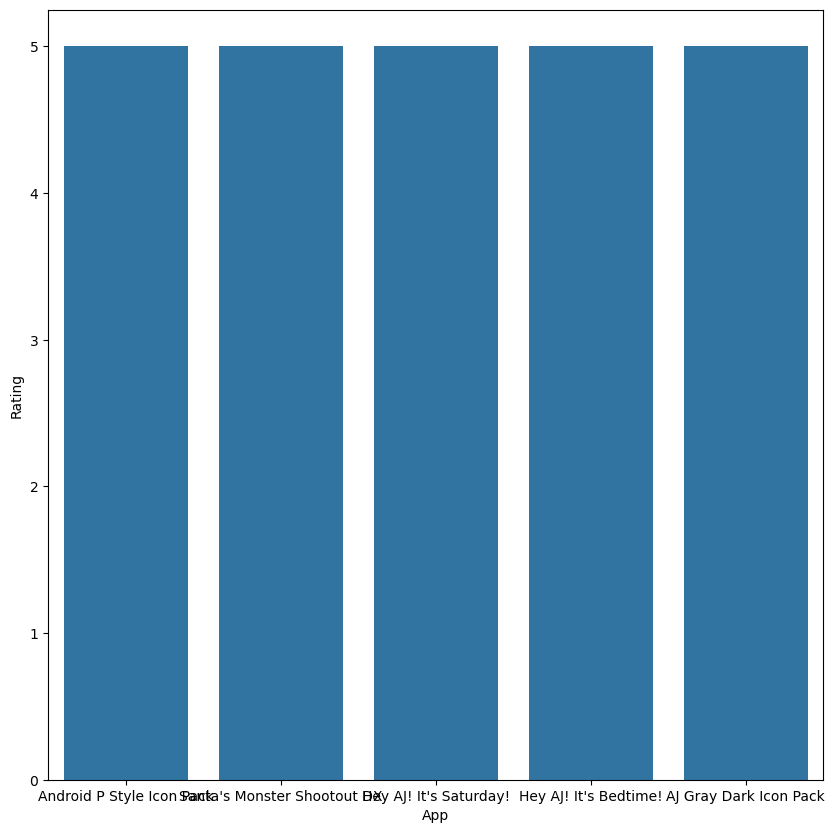

In [151]:
plt.figure(figsize=(10,10))
sns.barplot(x="App",y="Rating",data=df[df['Type']=='Paid'].sort_values(by="Rating",ascending=False).head(5))

top 5 apps in the free categroy


<Axes: xlabel='App', ylabel='Rating'>

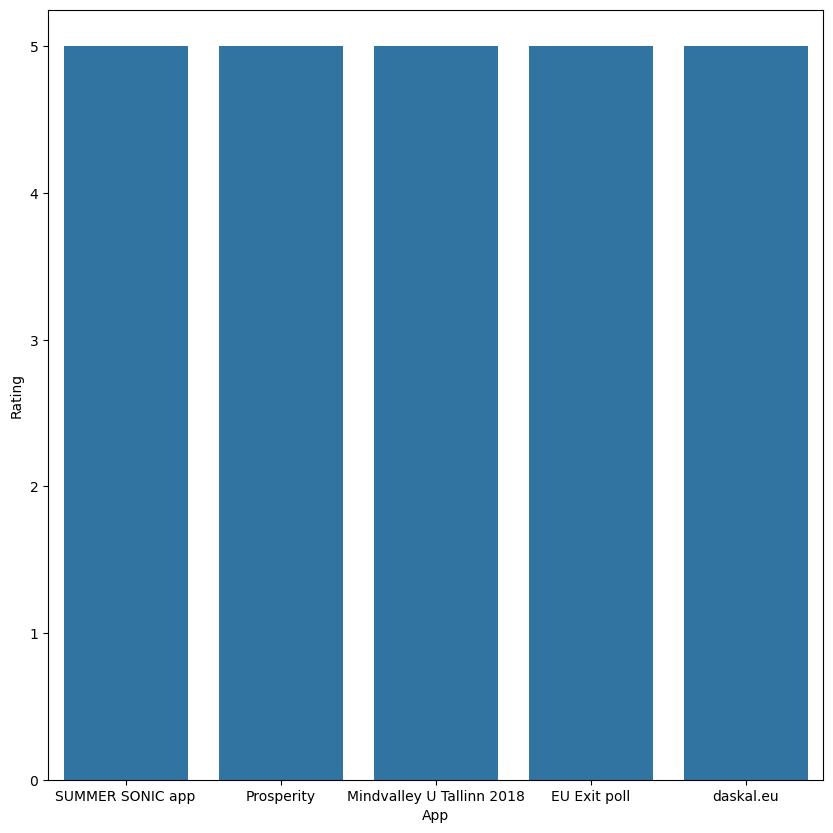

In [152]:
plt.figure(figsize=(10,10))
sns.barplot(x="App",y="Rating",data=df[df['Type']=='Free'].sort_values(by="Rating",ascending=False).head(5))

In [153]:
import plotly.graph_objects as go

# Filter and sort the data
filtered_df = df[df['Type'] == 'Free'].sort_values(by='Rating', ascending=False).head(10)

# Define stages and values for the funnel chart
stages = filtered_df['App']
values = filtered_df['Rating']

# Create the funnel chart
fig = go.Figure(go.Funnel(
    y=stages,
    x=values,
    textinfo="value+percent initial",
    hovertemplate='<b>%{y}</b><br>Rating: %{x}<extra></extra>',
    marker=dict(color='blue')
))

# Update the layout
fig.update_layout(
    title="Funnel Chart for Top 5 Highest Rated Free Apps",
    funnelmode="stack"
)

# Show the chart
fig.show()


In [154]:
import plotly.graph_objects as go

# Filter and sort the data
filtered_df = df[df['Type'] == 'Free'].sort_values(by='Rating', ascending=False).head(5)

# Define stages and values for the funnel chart
stages = filtered_df['App']
values = filtered_df['Rating']

# Create the funnel chart
fig = go.Figure(go.Funnel(
    y=stages,
    x=values,
    textposition = "inside",
    textinfo="value+percent initial",
    
    hovertemplate='<b>%{y}</b><br>Rating: %{x}<extra></extra>',
    marker=dict(color='blue')
))

# Update the layout
fig.update_layout(
    title="Funnel Chart for Top 5 Highest Rated Free Apps",
    funnelmode="stack"
)

# Show the chart
fig.show()


top 5 free apps with highest number of reviews

<Axes: xlabel='App', ylabel='Reviews'>

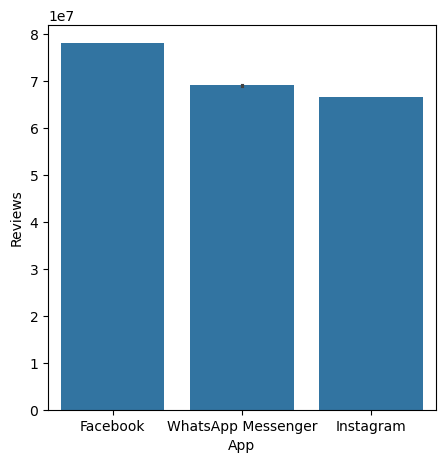

In [155]:
plt.figure(figsize=(5,5))
sns.barplot(x="App",y="Reviews",data=df[df["Type"]=="Free"].sort_values(by="Reviews",ascending=False).head(6))


In [156]:
from plotly import graph_objects as go

# Filter and sort the data
filtered_df = df[df['Type'] == 'Free'].sort_values(by='Reviews', ascending=False).head(10)

# Define stages and values for the funnel chart
stages = filtered_df['App']
values = filtered_df['Reviews']
fig = go.Figure(go.Funnel(
    y = stages,
    x = values,
    textposition = "inside",
    textinfo = "value+percent initial",
    opacity = 0.65, marker = {"color": ["deepskyblue", "lightsalmon", "tan", "teal", "silver"],
    "line": {"width": [4, 2, 2, 3, 1, 1], "color": ["yellow", "black", "blue", "yellow", "red"]}},
    connector = {"line": {"color": "royalblue", "dash": "dot", "width": 3}})
    )

fig.show()

In [157]:

filtered_df = df[df['Type'] == 'Free'].sort_values(by='Rating', ascending=False).head(10)

# Define stages and values for the funnel chart
stages = filtered_df['App']
values = filtered_df['Rating']

# Create the pie chart
pie_fig = go.Figure(go.Pie(
    labels=stages,
    values=values,
    textinfo="label+value+percent",
    hovertemplate='<b>%{label}</b><br>Rating: %{value}<br>Percent: %{percent:.2%}<extra></extra>',
    marker=dict(colors=colors)
))

# Update the layout
pie_fig.update_layout(
    title="Pie Chart of Top 10 Highest Rated Free Apps"
)

# Show the pie chart
pie_fig.show()


top 5 rated free apps with respect to rating  with size representing the installs 

In [158]:


filtered_df = df[df['Type'] == 'Free'].sort_values(by='Reviews', ascending=False).head(10)

# Define stages and values for the funnel chart
stages = filtered_df['App']
values = filtered_df['Reviews']

fig = px.scatter(filtered_df,
                 x='Rating',
                 y='App',
                 size='Installs',  # Replace 'Downloads' with your actual column if available
                 color='Reviews',
                 title='Top 5 Highest Rated Free Apps with Bubble Size Representing Reviews',
                 labels={'App': 'App', 'Rating': 'Rating'},
                 height=600)

# Show the chart
fig.show()


<Axes: xlabel='App', ylabel='Reviews'>

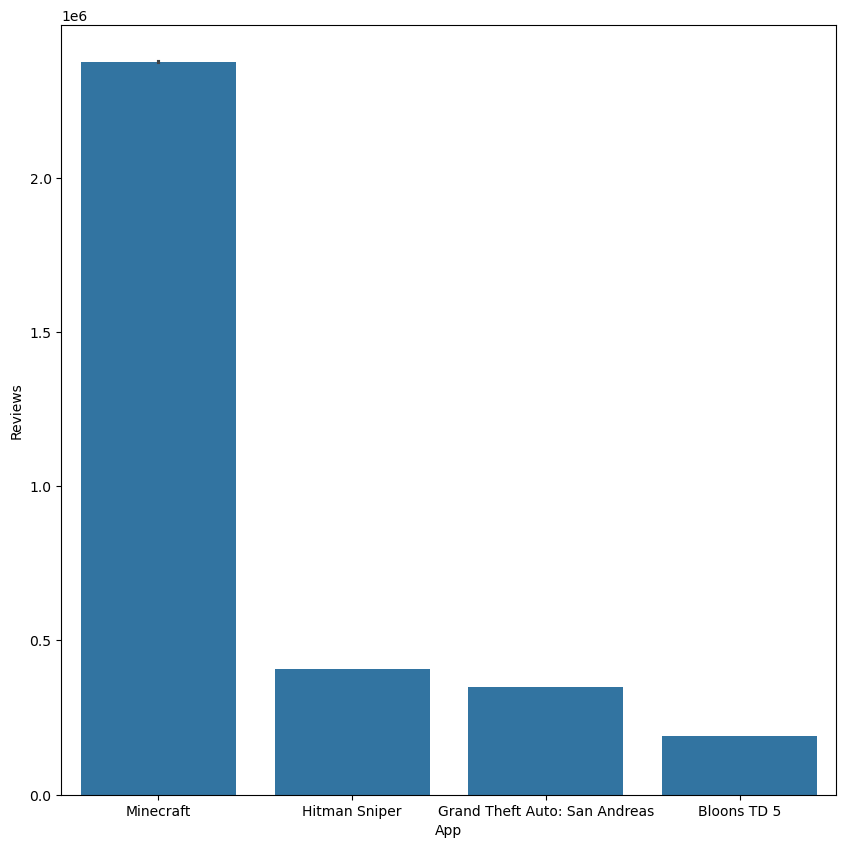

In [159]:
plt.figure(figsize=(10,10))
sns.barplot(x="App",y="Reviews",data=df[df["Type"]=="Paid"].sort_values(by="Reviews",ascending=False).head(5))


In [160]:

filtered_df = df[df['Type'] == 'Paid'].sort_values(by='Reviews', ascending=False).head(5)

# Define stages and values for the funnel chart
stages = filtered_df['App']
values = filtered_df['Reviews']

# Create the pie chart
pie_fig = go.Figure(go.Pie(
    labels=stages,
    values=values,
    textinfo="label+value+percent",
    hovertemplate='<b>%{label}</b><br>Reviews: %{value}<br>Percent: %{percent:.2%}<extra></extra>',
    marker=dict(colors=colors,line=dict(color='#000000', width=2))
))

# Update the layout
pie_fig.update_layout(
    title="Pie Chart of Top 5 Highest Reveiwed paid Apps"
)

# Show the pie chart
pie_fig.show()


In [161]:



filtered_df = df[df['Type'] == 'Paid'].sort_values(by='Reviews', ascending=False).head(5)

# Define stages and values for the funnel chart
stages = filtered_df['App']
values = filtered_df['Reviews']

fig = px.scatter(filtered_df,
                 x='Rating',
                 y='App',
                 size='Installs',  # Replace 'Downloads' with your actual column if available
                 color='Reviews',
                 title='Top 5 Highest Rated Paid Apps with Bubble Size Representing Reviews',
                 labels={'App': 'App', 'Rating': 'Rating'},
                 height=600)

# Show the chart
fig.show()


districbution of rating by update year

In [162]:
df["Update year"]=df["Last Updated"].dt.year

<Axes: xlabel='Update year', ylabel='Rating'>

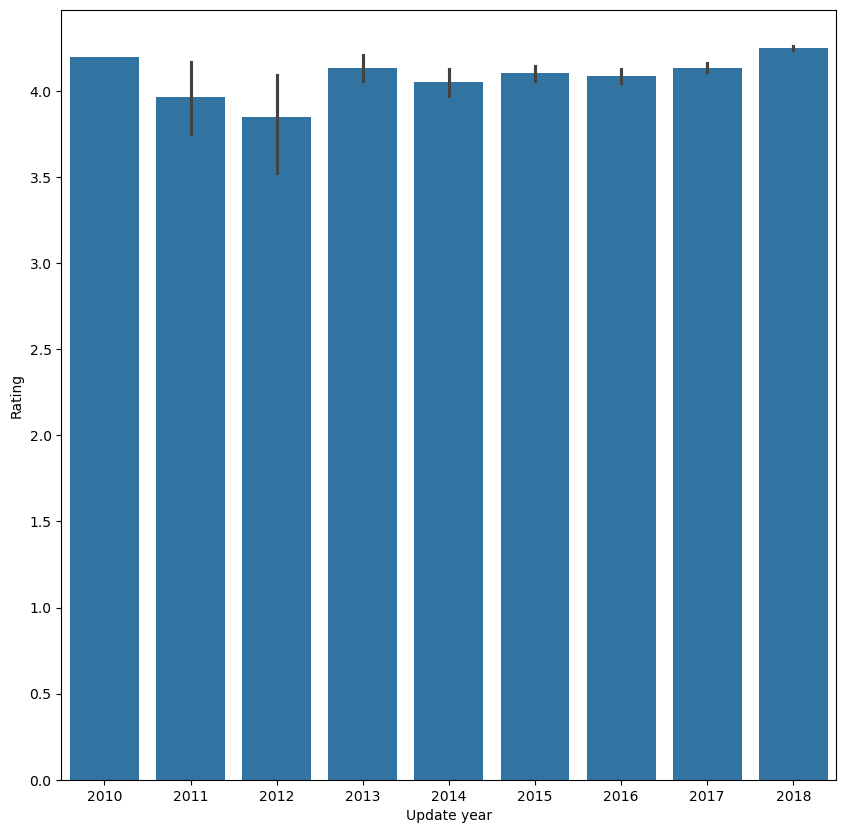

In [163]:
plt.figure(figsize=(10,10))
sns.barplot(x="Update year",y="Rating",data=df)


. What is/are the insight(s) found from the chart?
The average rating has shown an improvement, rising from approximately 3.5 in 2010 to nearly 4.5 in 2018. This indicates a general trend of increasing satisfaction among users with the product over the years.



A regplot is a statistical visualization that reveals the relationship between two continuous variables through a scatter plot and a best-fit linear regression line. It helps identify trends, patterns, and the strength of the correlation between variables. I utilized regplot to explore the distribution of Ratings with respect to Update Years.

<Axes: xlabel='Update year', ylabel='Rating'>

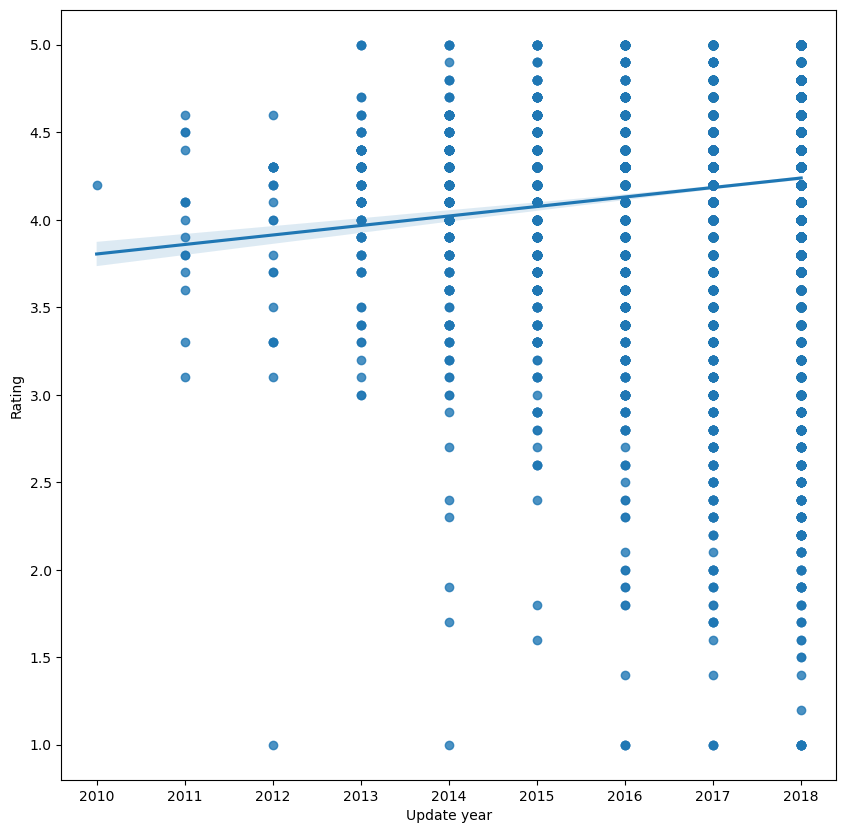

In [164]:
plt.figure(figsize=(10,10))
sns.regplot(x="Update year",y="Rating",data=df)

districbution of Reviews by update year

/tmp/ipykernel_8690/2818336270.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




<Axes: xlabel='Update year', ylabel='Reviews'>

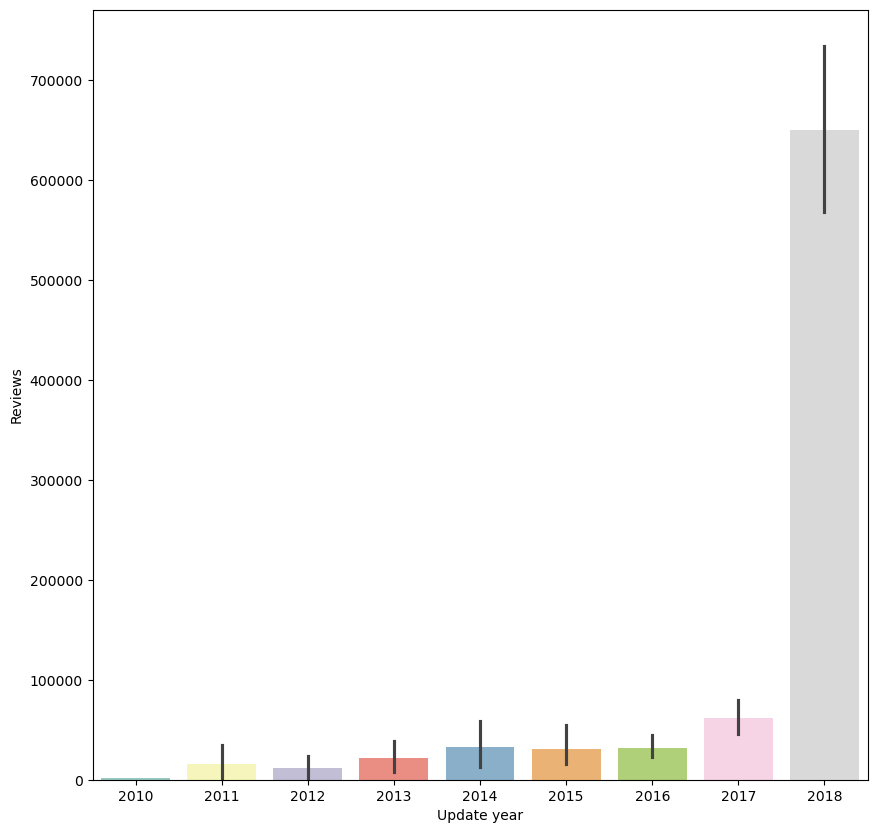

In [165]:
plt.figure(figsize=(10,10))
sns.barplot(x="Update year",y="Reviews",data=df, palette='Set3')



Possible Explanations for Rating Increase:

Introduction of New Features: Developers may be adding new features, enhancing the product's functionality, and providing users with more value.

Enhancements in Reliability and Usability: The product may be improving in terms of reliability and user-friendliness, contributing to a better overall experience.

Increased Popularity: A growing user base could lead to a more positive user experience, as popularity often correlates with user satisfaction.

In [166]:
import plotly.express as px
fig = px.scatter_3d(df, x='Update year', y='Reviews', z='Installs',
              color='Category')
fig.show()

calculating revenu for each app

In [167]:
df["Revenue"]=df["Installs"]*df["Price"]
df

,App,Category,Rating,Reviews,Size in mb,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_category,Update year,Revenue
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,Moderate,2018,0.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,High,2018,0.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,Very High,2018,0.0
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,Top Notch,2018,0.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,More than moderate,2018,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10519,Driving Suv Toyota Car Simulator,FAMILY,3.7,187,53.0,10000,Free,0.0,Everyone,Simulation,2017-11-12,1,4.0 and up,Moderate,2017,0.0
10520,Navy Gunner Shoot War 3D,GAME,4.0,103199,3.6,10000000,Free,0.0,Teen,Action,2018-08-02,1.0.7.8,4.2 and up,Very High,2018,0.0
10521,Drift Legends,GAME,4.2,33788,9.5,1000000,Free,0.0,Everyone,Racing,2018-03-29,1.8.5,4.1 and up,High,2018,0.0
10522,FK,MEDICAL,4.4,1517,0.0,100000,Free,0.0,Everyone,Medical,2018-07-13,2.5.9,2.3 and up,More than moderate,2018,0.0


In [168]:
df[df["Type"]=="Paid"]

,App,Category,Rating,Reviews,Size in mb,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_category,Update year,Revenue
234,TurboScan: scan documents and receipts in PDF,BUSINESS,4.7,11442,0.0,100000,Paid,4.99,Everyone,Business,2018-03-25,1.5.2,4.0 and up,More than moderate,2018,499000.0
235,Tiny Scanner Pro: PDF Doc Scan,BUSINESS,4.8,10295,14.0,100000,Paid,4.99,Everyone,Business,2017-04-11,3.4.6,3.0 and up,More than moderate,2017,499000.0
291,Tiny Scanner Pro: PDF Doc Scan,BUSINESS,4.8,10295,35.0,100000,Paid,4.99,Everyone,Business,2017-04-11,3.4.6,3.0 and up,More than moderate,2017,499000.0
427,Puffin Browser Pro,COMMUNICATION,4.0,18247,14.0,100000,Paid,3.99,Everyone,Communication,2018-07-05,7.5.3.20547,4.1 and up,More than moderate,2018,399000.0
476,"Moco+ - Chat, Meet People",DATING,4.2,1545,0.0,10000,Paid,3.99,Mature 17+,Dating,2018-06-19,2.6.139,4.1 and up,Moderate,2018,39900.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10453,"Talkie Pro - Wi-Fi Calling, Chats, File Sharing",COMMUNICATION,4.5,201,7.0,1000,Paid,2.99,Everyone,Communication,2018-01-06,Varies with device,Varies with device,Low,2018,2990.0
10457,WiFi Monitor Pro - analyzer of Wi-Fi networks,TOOLS,4.6,85,41.0,1000,Paid,2.99,Everyone,Tools,2018-07-05,1.9,4.0 and up,Low,2018,2990.0
10459,SCI-FI UI,FAMILY,4.7,15,3.9,100,Paid,1.99,Everyone,Entertainment,2018-04-16,0.0.53,1.6 and up,Low,2018,199.0
10460,Wi-Fi Rabbit Unlock Key,TOOLS,4.5,142,8.9,5000,Paid,1.00,Everyone,Tools,2011-06-26,1.0.0,2.1 and up,Moderate,2011,5000.0


top 10 categories by avg revenue

In [169]:

category_revenue=df.groupby("Category")["Revenue"].mean().sort_values(ascending=False).head(10)
category_revenue

Category
LIFESTYLE          159512.297507
FAMILY              96766.392896
FINANCE             72385.292901
WEATHER             55658.533333
PHOTOGRAPHY         45806.035890
GAME                35483.604901
MEDICAL             29769.394013
PERSONALIZATION     27474.088396
EDUCATION           15815.657895
COMMUNICATION       11541.751359
Name: Revenue, dtype: float64

<Axes: xlabel='Revenue'>

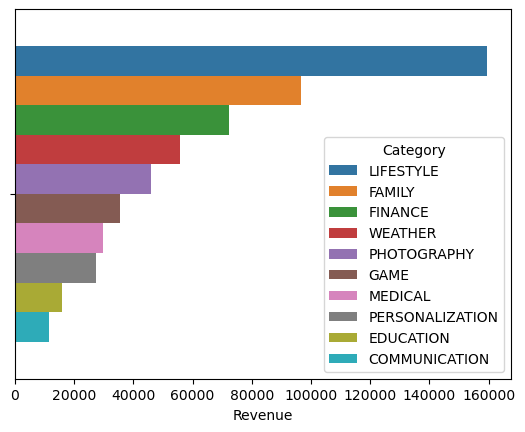

In [170]:
sns.barplot(x=category_revenue, hue=category_revenue.index,legend=True)


plotting the graph for top 10 categiry of apps by avg revenue and with their respective installs

In [171]:
category_agg = df.groupby('Category').agg({'Revenue': 'mean', 'Installs': 'sum'})

category_agg = category_agg.sort_values(by='Revenue', ascending=False).head(10)

print(category_agg)

                       Revenue     Installs
Category                                   
LIFESTYLE        159512.297507    525872579
FAMILY            96766.392896  10240705454
FINANCE           72385.292901    875597583
WEATHER           55658.533333    425888500
PHOTOGRAPHY       45806.035890   9956231655
GAME              35483.604901  34991898254
MEDICAL           29769.394013     53085837
PERSONALIZATION   27474.088396   2265352906
EDUCATION         15815.657895    841452000
COMMUNICATION     11541.751359  31445724321


                       Revenue     Installs
Category                                   
LIFESTYLE        159512.297507    525872579
FAMILY            96766.392896  10240705454
FINANCE           72385.292901    875597583
WEATHER           55658.533333    425888500
PHOTOGRAPHY       45806.035890   9956231655
GAME              35483.604901  34991898254
MEDICAL           29769.394013     53085837
PERSONALIZATION   27474.088396   2265352906
EDUCATION         15815.657895    841452000
COMMUNICATION     11541.751359  31445724321


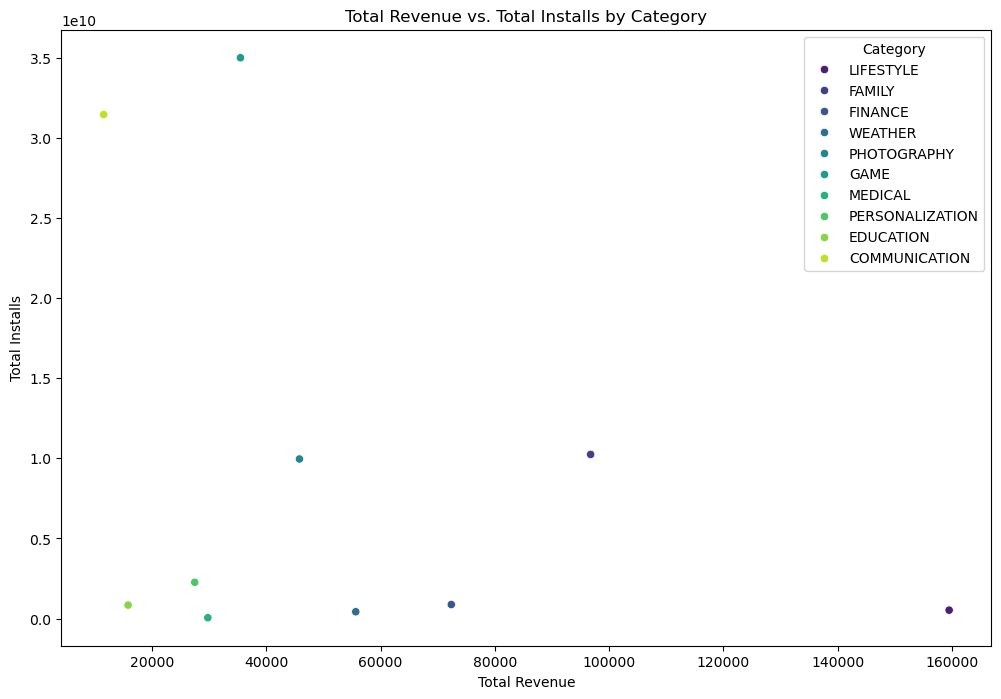

In [172]:
category_agg = df.groupby('Category').agg({'Revenue': 'mean', 'Installs': 'sum'})

category_agg = category_agg.sort_values(by='Revenue', ascending=False).head(10)

print(category_agg)


# Plotting the scatter plot
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Revenue', y='Installs', hue=category_agg.index, data=category_agg, palette='viridis')

plt.title('Total Revenue vs. Total Installs by Category')
plt.xlabel('Total Revenue')
plt.ylabel('Total Installs')

plt.show()

In [173]:
import plotly.express as px

# Plotting with Plotly
fig = px.scatter(category_agg, x="Revenue", y="Installs", color=category_agg.index,
                 size="Revenue", hover_data=[category_agg.index],
                 title='Total Revenue vs. Total Installs by Category')

# Show the plot
fig.show()


In [174]:
category_agg = df.groupby('Category').agg({'Revenue': 'mean', 'Installs': 'sum','Reviews':'mean','Rating':'mean'})

category_agg = category_agg.sort_values(by='Revenue', ascending=False).head(10)

print(category_agg)

import plotly.express as px
import pandas as pd

fig = px.scatter(category_agg, x="Revenue", y="Installs", size="Reviews", color=category_agg.index,
                 hover_name="Rating", size_max=60,labels={'color':'Category'})

# Show the plot
fig.show()

                       Revenue     Installs       Reviews    Rating
Category                                                           
LIFESTYLE        159512.297507    525872579  3.445171e+04  4.117729
FAMILY            96766.392896  10240705454  2.131832e+05  4.202708
FINANCE           72385.292901    875597583  4.927474e+04  4.152958
WEATHER           55658.533333    425888500  1.946655e+05  4.262667
PHOTOGRAPHY       45806.035890   9956231655  6.478574e+05  4.199387
GAME              35483.604901  34991898254  1.420353e+06  4.289228
MEDICAL           29769.394013     53085837  3.472969e+03  4.215789
PERSONALIZATION   27474.088396   2265352906  2.354799e+05  4.339840
EDUCATION         15815.657895    841452000  2.556383e+05  4.384211
COMMUNICATION     11541.751359  31445724321  2.170546e+06  4.177174


In [175]:

df.isnull().sum()

App                  0
Category             0
Rating               0
Reviews              0
Size in mb           0
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          0
Android Ver          0
Installs_category    0
Update year          0
Revenue              0
dtype: int64

NUMMBER OF APPS IN EACH CATEGROY

In [176]:
category_counts=df["Category"].value_counts()
category_counts

Category
FAMILY                 1920
GAME                   1114
TOOLS                   818
MEDICAL                 456
BUSINESS                421
PRODUCTIVITY            414
PERSONALIZATION         374
COMMUNICATION           368
LIFESTYLE               361
FINANCE                 355
HEALTH_AND_FITNESS      334
SPORTS                  334
PHOTOGRAPHY             326
SOCIAL                  287
NEWS_AND_MAGAZINES      261
SHOPPING                251
TRAVEL_AND_LOCAL        240
DATING                  231
BOOKS_AND_REFERENCE     213
VIDEO_PLAYERS           173
EDUCATION               152
ENTERTAINMENT           143
MAPS_AND_NAVIGATION     132
FOOD_AND_DRINK          127
HOUSE_AND_HOME           87
LIBRARIES_AND_DEMO       83
AUTO_AND_VEHICLES        83
WEATHER                  75
ART_AND_DESIGN           64
EVENTS                   62
PARENTING                60
COMICS                   59
BEAUTY                   53
Name: count, dtype: int64

In [177]:
import pandas as pd
import plotly.express as px


category_counts = df['Category'].value_counts().reset_index()
category_counts.columns = ['Category', 'Apps']
fig = px.bar(category_counts, x='Category', y='Apps',color="Category" ,title='Number of Apps in Each Category')
fig.show()


App Ratings Distribution:

Histogram: Displaying the distribution of app ratings.
App Reviews vs. Installs:


In [178]:
import plotly.express as px
fig=px.histogram(df,x="Rating",color_discrete_sequence=['indianred'] )# color of histogram bars)
fig.show()

Distrubution of app reviewss vs installs

In [179]:
import pandas as pd
import plotly.express as px
fig = px.histogram(df, x="Reviews", y="Installs")
fig.show()

In [180]:
import pandas as pd
import plotly.express as px
fig = px.scatter(df, x='Installs', y='Reviews', title='Distribution of App Reviews vs Installs',
                 labels={'Installs': 'Number of Installs', 'Reviews': 'Number of Reviews'},
                 hover_data=['App', 'Category'])
fig.show()


In [181]:
import plotly.express as px
fig = px.histogram(df, x="Rating", color="Category").update_xaxes(categoryorder='total descending')
fig.show()

In [182]:
import plotly.express as px
fig = px.histogram(df, x="Rating", color="Installs_category").update_xaxes(categoryorder='total descending')
fig.show()

In [183]:
df.to_csv("preprocessed_GPS.csv")

In [184]:
df0=pd.read_csv("preprocessed_GPS.CSV")
df0

FileNotFoundError: [Errno 2] No such file or directory: 'preprocessed_GPS.CSV'

In [ ]:
df.dtypes

In [ ]:

import numpy as np
import pandas as pd


df2=pd.read_csv("googleplaystore_user_reviews.csv")
df2.info()


In [ ]:
df2.describe()

In [ ]:
df2.head()

In [ ]:
df2.tail()

In [ ]:

print('User Reviews Data Rows count:',df2.shape[0])
print('User Reviews Data Columns count:',df2.shape[1])


In [ ]:
print('User Reviews Data Info:')
df2.info()



In [ ]:
print('User Reviews Data Duplicate Value Count:',len(df2[df2.duplicated()]))

In [ ]:
def null_percent(data_fm):
    null_info = pd.DataFrame(index=data_fm.columns)
    null_info["datatype"] = data_fm.dtypes
    null_info["not null values"] = data_fm.count()
    null_info["null value"] = data_fm.isnull().sum()
    null_info["null value(%)"] = round(data_fm.isnull().mean() * 100, 2)
    return null_info
# Display the percentage of null values for User Reviews Data
print('Null value % in User Reviews Data:', null_percent(df2), sep='\n')

In [ ]:
print('Null Value Heatmap for Play Store Data')
sns.heatmap(df2.isnull(), cbar=False)
plt.show()

User reviews dataset: 64,295 rows, 5 columns, 33,616 instances of duplicated rows.
Missing values in columns: 'Translated_Review' (41.79% null value), 'Sentiment' (41.78% null value), 'Sentiment_Polarity' (41.78% null values), 'Sentiment_Subjectivity' (41.78% null values).
Primary aim: Uncover key factors contributing to app engagement and success in the Android market using this data.

In [ ]:
print('User Reviews Dataset Columns:',df2.columns,sep='\n')

In [ ]:
print('User Reviews Dataset Description:',df2.describe(include='all'),sep='\n')


Descriptions for User Reviews Dataset:
App: The app's name with a brief description.

Translated_Review: English translation of the user's review.

Sentiment: The reviewer’s attitude categorized as 'Positive', 'Negative', or 'Neutral'.

Sentiment_Polarity: The review's polarity, ranging from -1 (Negative) to 1 (Positive).

Sentiment_Subjectivity: The score indicates the degree to which a reviewer’s opinion aligns with the general public’s opinion, with a range of [0, 1]. Higher scores suggest opinions closer to the general public, while lower scores indicate more factual information in the review

In [ ]:
# Printing unique values for each variable in the User Reviews Dataset
print('Unique Values for each variable in User Reviews Dataset:', end='\n\n')

for i in df2.columns.tolist():
    print("No. of unique values in ", i, "is ->", df2[i].nunique())

In [ ]:
df2.drop_duplicates(inplace=True)
print('User Reviews Data Rows count:',df2.shape[0])
print('User Reviews Data Columns count:',df2.shape[1])

In [ ]:
df2['Sentiment_Polarity'].fillna(df2['Sentiment_Polarity'].median(), inplace=True)
df2['Sentiment_Subjectivity'].fillna(df2['Sentiment_Subjectivity'].median(), inplace=True)
df2['Sentiment'].fillna(df2['Sentiment'].mode()[0], inplace=True)
df2['Translated_Review'].fillna('No review', inplace=True)

In [ ]:
user_reviews_missing_updated = df2.isnull().sum()
print('Updated number of missing values in User Reviews dataset:')
print(user_reviews_missing_updated)


In [ ]:
df2 = df2.drop('Translated_Review', axis=1)

In [ ]:

# Chart - 1 visualization code
# Distribution of Sentiment Polarity
# Set up the visualisation settings
sns.set(style='whitegrid')

# Plot distribution of Sentiment Polarity
plt.figure(figsize=(10, 5))
plt.title('Distribution of Sentiment Polarity',size=20)
sns.histplot(df2['Sentiment_Polarity'], bins=50, kde=True)
plt.xlabel('Sentiment Polarity',size=15)
plt.ylabel('Frequency',size=15)
plt.show()


In [ ]:
df0=pd.read_csv("preprocessed_GPS.csv")

In [ ]:



# Chart - 10 visualizaftion code
# Sentiment counts across categories.
# Set style to 'whitegrid'
sns.set(style='whitegrid')

# Set the figure size
plt.figure(figsize=(14, 6))

# Merging the Play Store data with the User Reviews data
merged_df = pd.merge(df0, df2, on='App', how='inner')

# Calculating the average sentiment polarity for each app
average_sentiment_polarity = merged_df.groupby('App')['Sentiment_Polarity'].mean()

# Merging the average sentiment polarity back to the original play store dataframe
play_store_sentiment_df = df0.join(average_sentiment_polarity, on='App')

# Count the number of sentiments for each category
grouped_df = merged_df.groupby(['Category', 'Sentiment']).size().unstack()

sns.barplot(data=grouped_df.reset_index(), x='Category', y='Positive', color='skyblue', label='Positive')
sns.barplot(data=grouped_df.reset_index(), x='Category', y='Negative', color='gray', bottom=grouped_df['Positive'], label='Negative')
sns.barplot(data=grouped_df.reset_index(), x='Category', y='Neutral', color='orange', bottom=grouped_df['Positive'] + grouped_df['Negative'], label='Neutral')

# Adding labels and title
plt.xlabel('Category',size=15)
plt.xticks(rotation=90)
plt.ylabel('Count of Sentiments',size=15)
plt.title('Sentiments vs Category',size=20)

# Adding legend
plt.legend(title='Sentiment')

# Displaying the plot
plt.show()


In [ ]:
merged_df

In [ ]:
# Chart - 11 visualization code
# Progression of update counts and the distribution of sentiment counts over time
# Group by 'Update Year' and count the number of updates
update_counts = merged_df.groupby("Update year")["App"].count()

# Group by 'Update Year' and 'Sentiment' and count occurrences
sentiment_counts = merged_df.groupby(['Update year', 'Sentiment']).size().unstack()

# Plotting
plt.figure(figsize=(8, 8))

# Plotting the number of updates received
plt.subplot(2, 1, 1)
plt.plot(update_counts.index, update_counts, label='Number of Updates', marker='o', color='gray')
plt.ylabel('Number of Updates', size=15)
plt.title('Number of Updates and Sentiments over Update Years', size=15)
plt.legend()

# Plotting sentiments
plt.subplot(2, 1, 2)
plt.plot(sentiment_counts.index, sentiment_counts['Positive'], label='Positive', marker='o')
plt.plot(sentiment_counts.index, sentiment_counts['Negative'], label='Negative', marker='o')
plt.plot(sentiment_counts.index, sentiment_counts['Neutral'], label='Neutral', marker='o')
plt.xlabel('Update Year', size=15)
plt.ylabel('Number of Sentiments', size=15)
plt.legend()

# Adjust layout for better readability
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
# Chart - 12 visualization code
# Relationship between Sentiment Polarity, Rating, and Installs
# Set style to 'whitegrid'
sns.set(style='whitegrid')

# Set up the plot
plt.figure(figsize=(10, 5))

# Scatter plot with size based on the number of installs
sns.scatterplot(x='Rating', y='Sentiment_Polarity', size='Installs', data=play_store_sentiment_df, sizes=(50, 300), edgecolor='white',legend=True)

# Customize the plot
plt.title('Sentiment Polarity by Rating and Installs', size=15)
plt.xlabel('Rating', size=15)
plt.ylabel('Average Sentiment Polarity', size=15)

# Show the plot
plt.show()

In [ ]:

# Chart - 13 visualization code
# Relationship between Sentiment Subjectivity and Sentiment Polarity
# Set the size of the figure
plt.figure(figsize=(12, 6))

# Create a scatter plot using seaborn
sns.scatterplot(data=merged_df, x='Sentiment_Subjectivity', y='Sentiment_Polarity', hue='Sentiment', palette='Set2')

# Set labels for the x and y axes
plt.xlabel('Sentiment Subjectivity', size=15)
plt.ylabel('Sentiment Polarity', size=15)

# Set the title of the plot
plt.title('Relationship between Sentiment Subjectivity and Sentiment Polarity', size=15)

# Display the plot
plt.show()

In [ ]:
#Chart - 14 - Correlation Heatmap visualization code
# Relationships among Rating, Reviews, Installs, Price, Sentiment_Polarity, and Sentiment_Subjectivity
# Selecting numerical columns from the merged dataframe
numerical_columns = merged_df[['Rating', 'Reviews', 'Installs', 'Price', 'Sentiment_Polarity', 'Sentiment_Subjectivity']]

# Create a correlation matrix
correlation_matrix = numerical_columns.corr()

# Create a heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='rocket', fmt=".2f")
plt.title('Correlation Heatmap',size=20)
plt.show()


In [ ]:
merged_df

In [ ]:
merged_df.to_csv("Mergetdatasets.csv",index=False)